In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Current directory: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Contents: ['.git', '.gitignore', 'requirements.bk.txt', 'README.md', 'data', 'results', 'requirements.txt', 'materials', 'src']
/home/ahbagheri/.cmdstan/cmdstan-2.38.0
cwd: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
first sys.path entries:
   /usr/lib/python312.zip
   /usr/lib/python3.12
   /usr/lib/python3.12/lib-dynload
   
   /home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages
project root guess: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
exists ./src ? True


In [2]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics/src/utils/utils.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


# Priors:
R2D2: https://arxiv.org/pdf/1609.00046

In [4]:
model_names = [("ab_baseline_simple_poi.stan", {}), ("ab_lasso.stan", {}), ("ab_horseshoe.stan", {}), ("ab_regularized_horseshoe.stan", {"p0": 2}), ("ab_r2d2.stan", {"R2_mean": 0.5,"R2_prec": 2.0, "cons_D2": 0.5})]

models = {}
for key in model_names:
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

In [7]:
import os
for key in models:
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    models[key]["az"] = az.from_netcdf(f"./results/ab/{filename}")

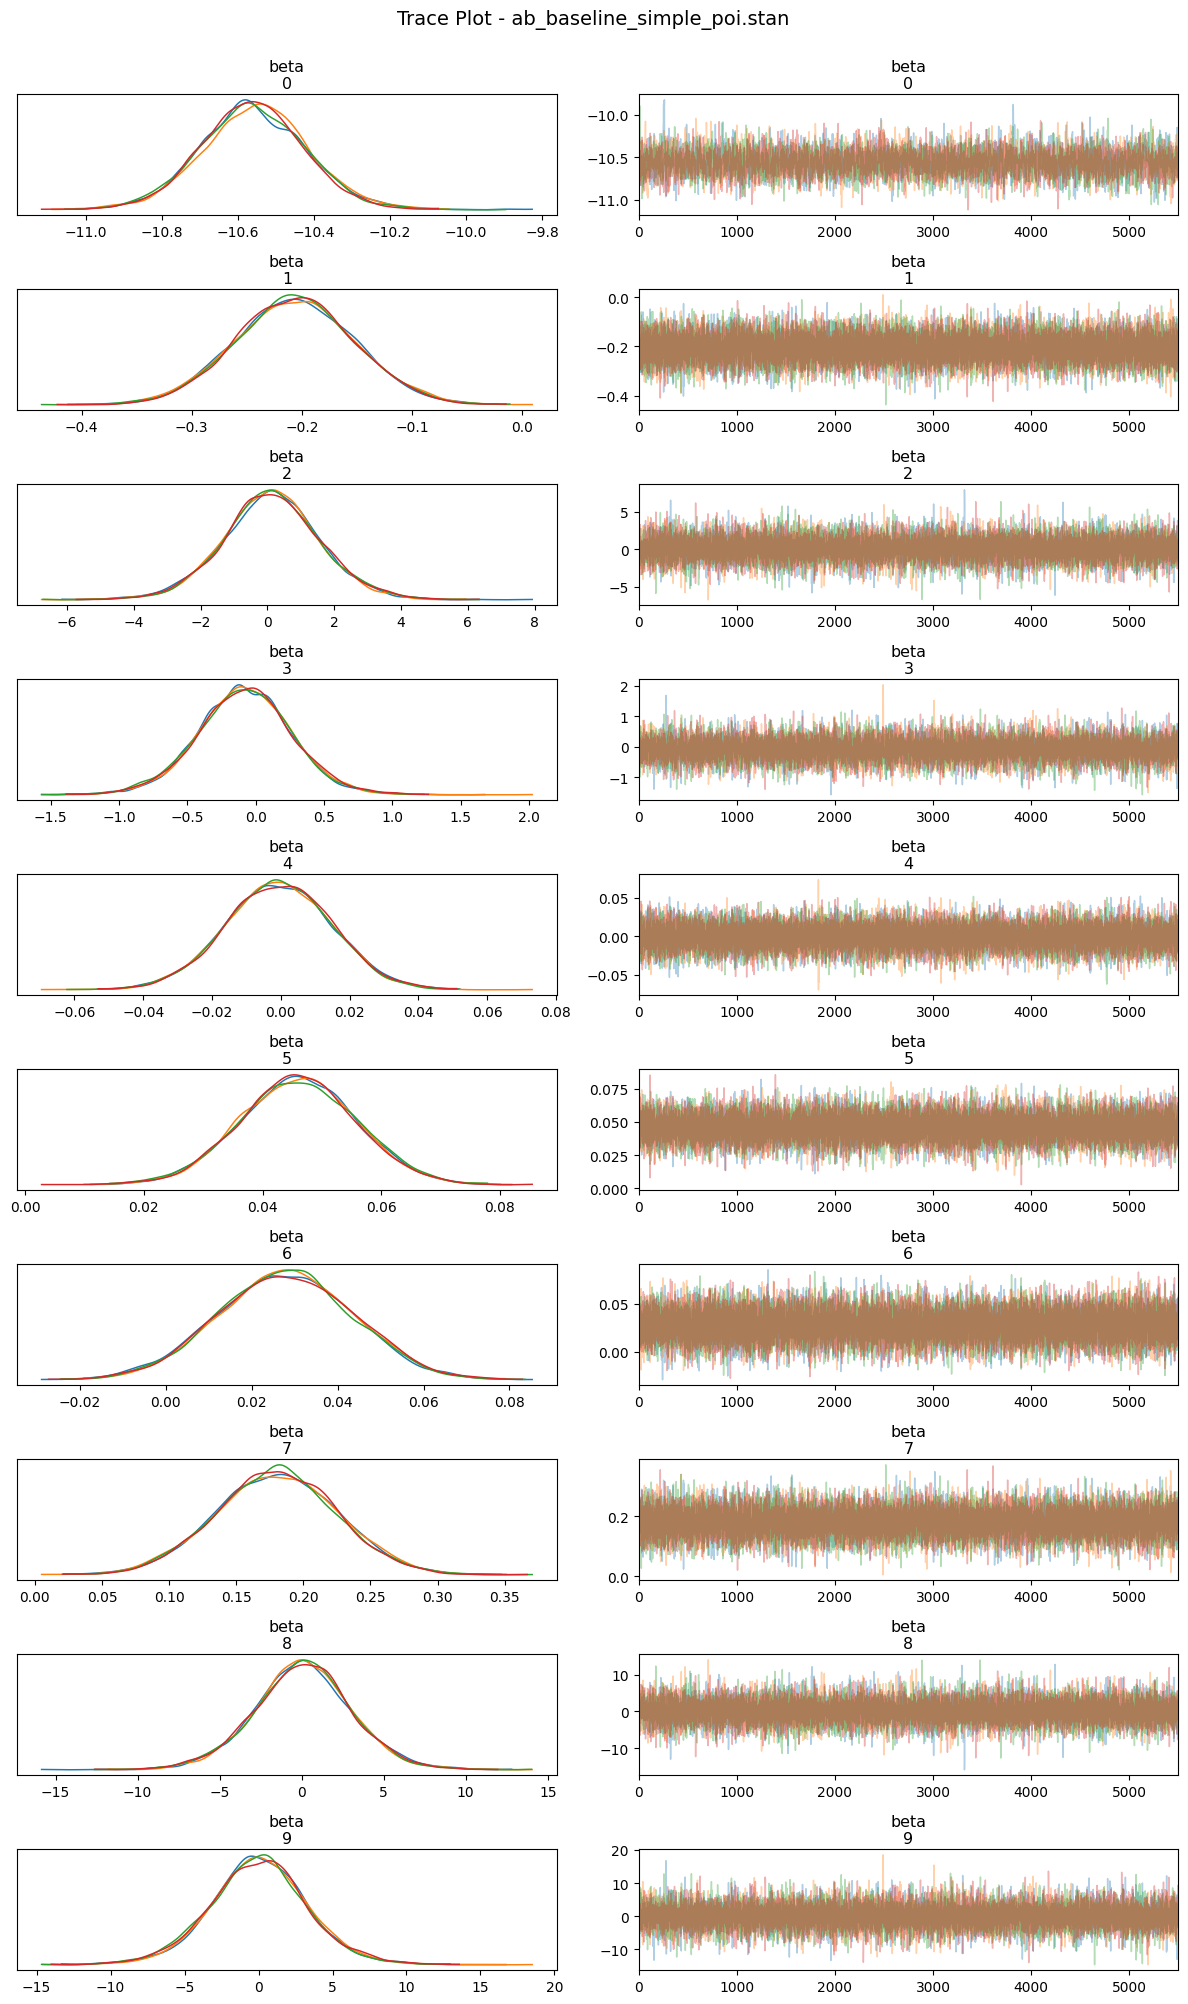

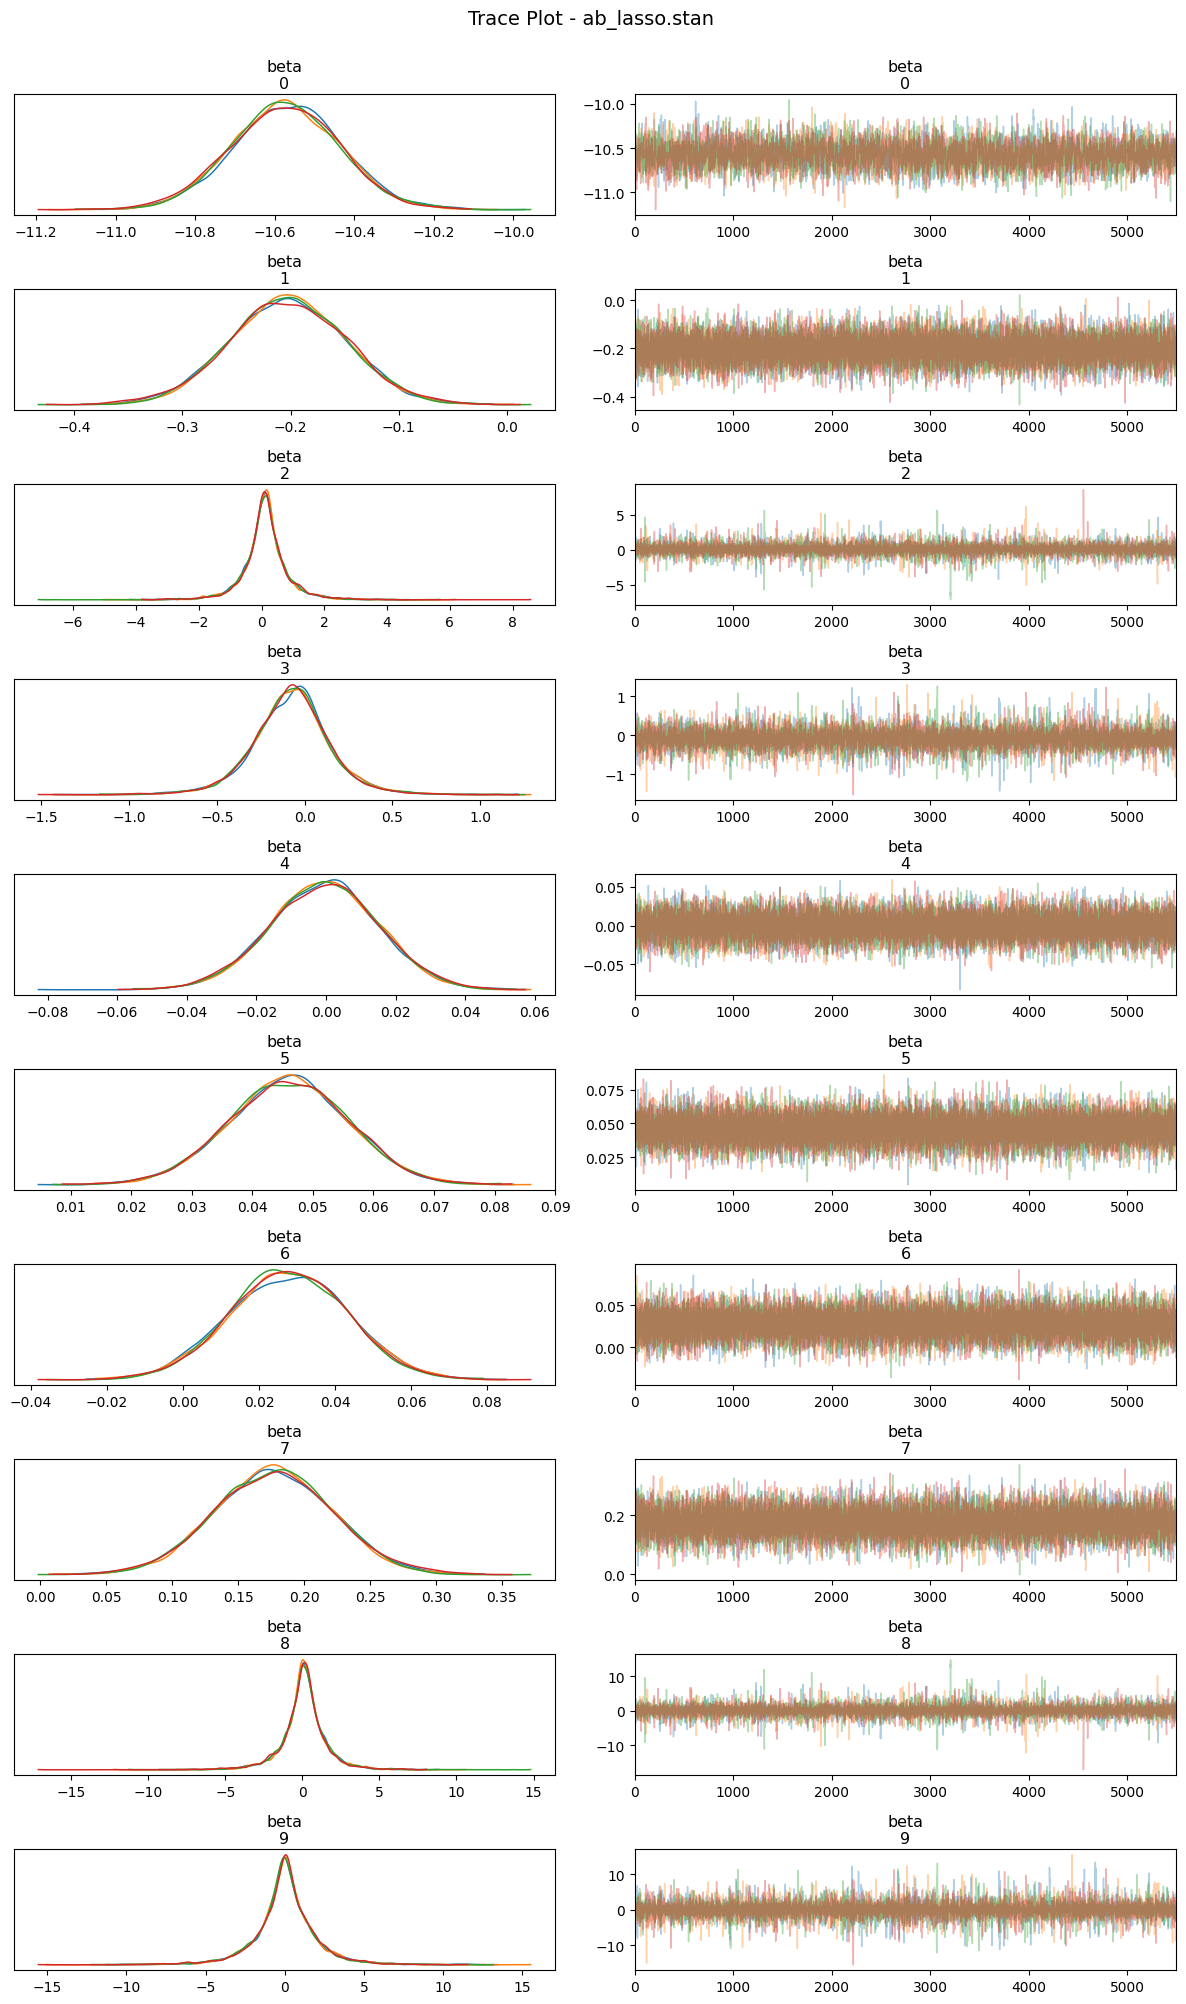

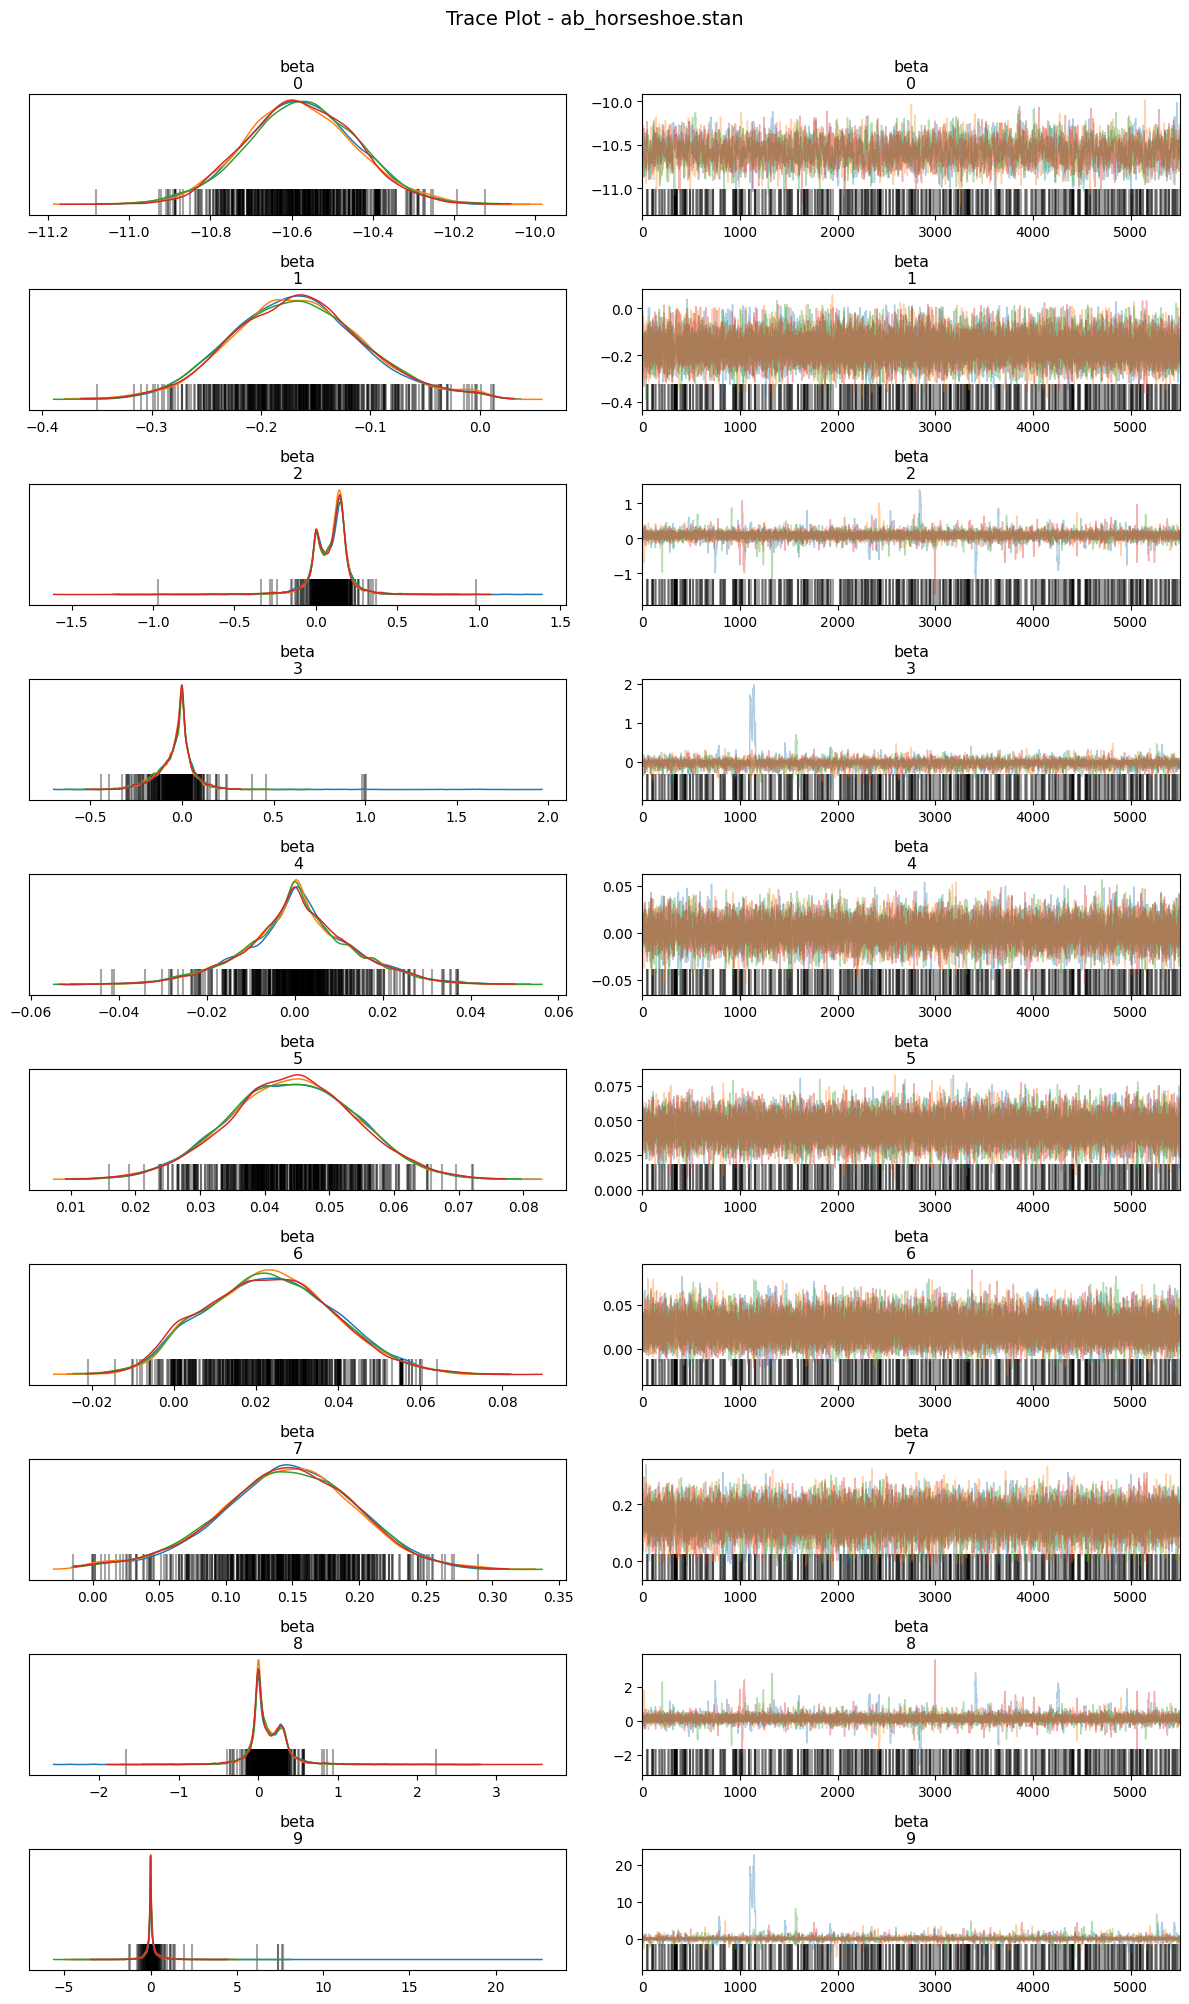

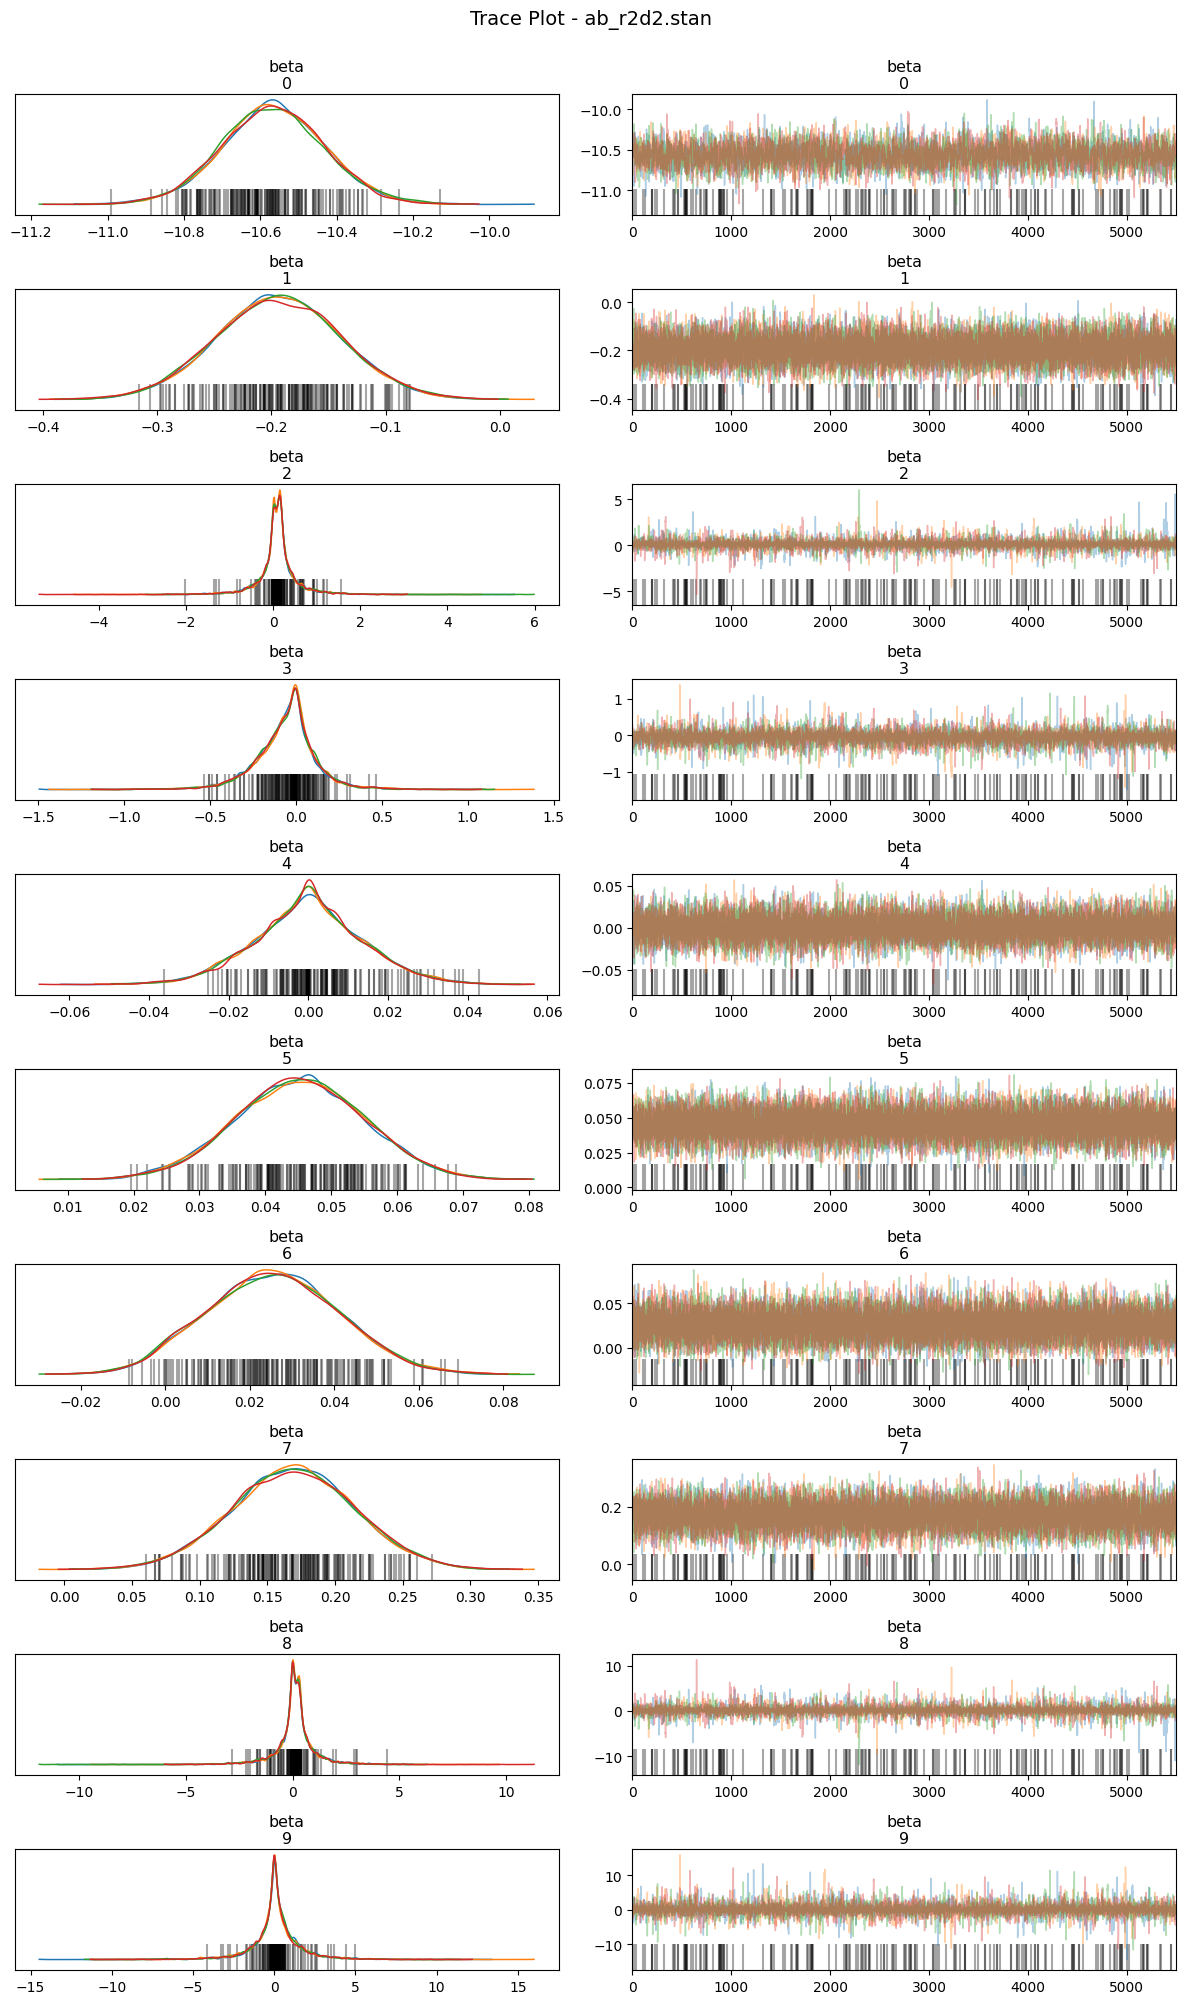

In [ ]:
for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_trace(poi_glm_data, var_names=["beta"], compact=False)
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

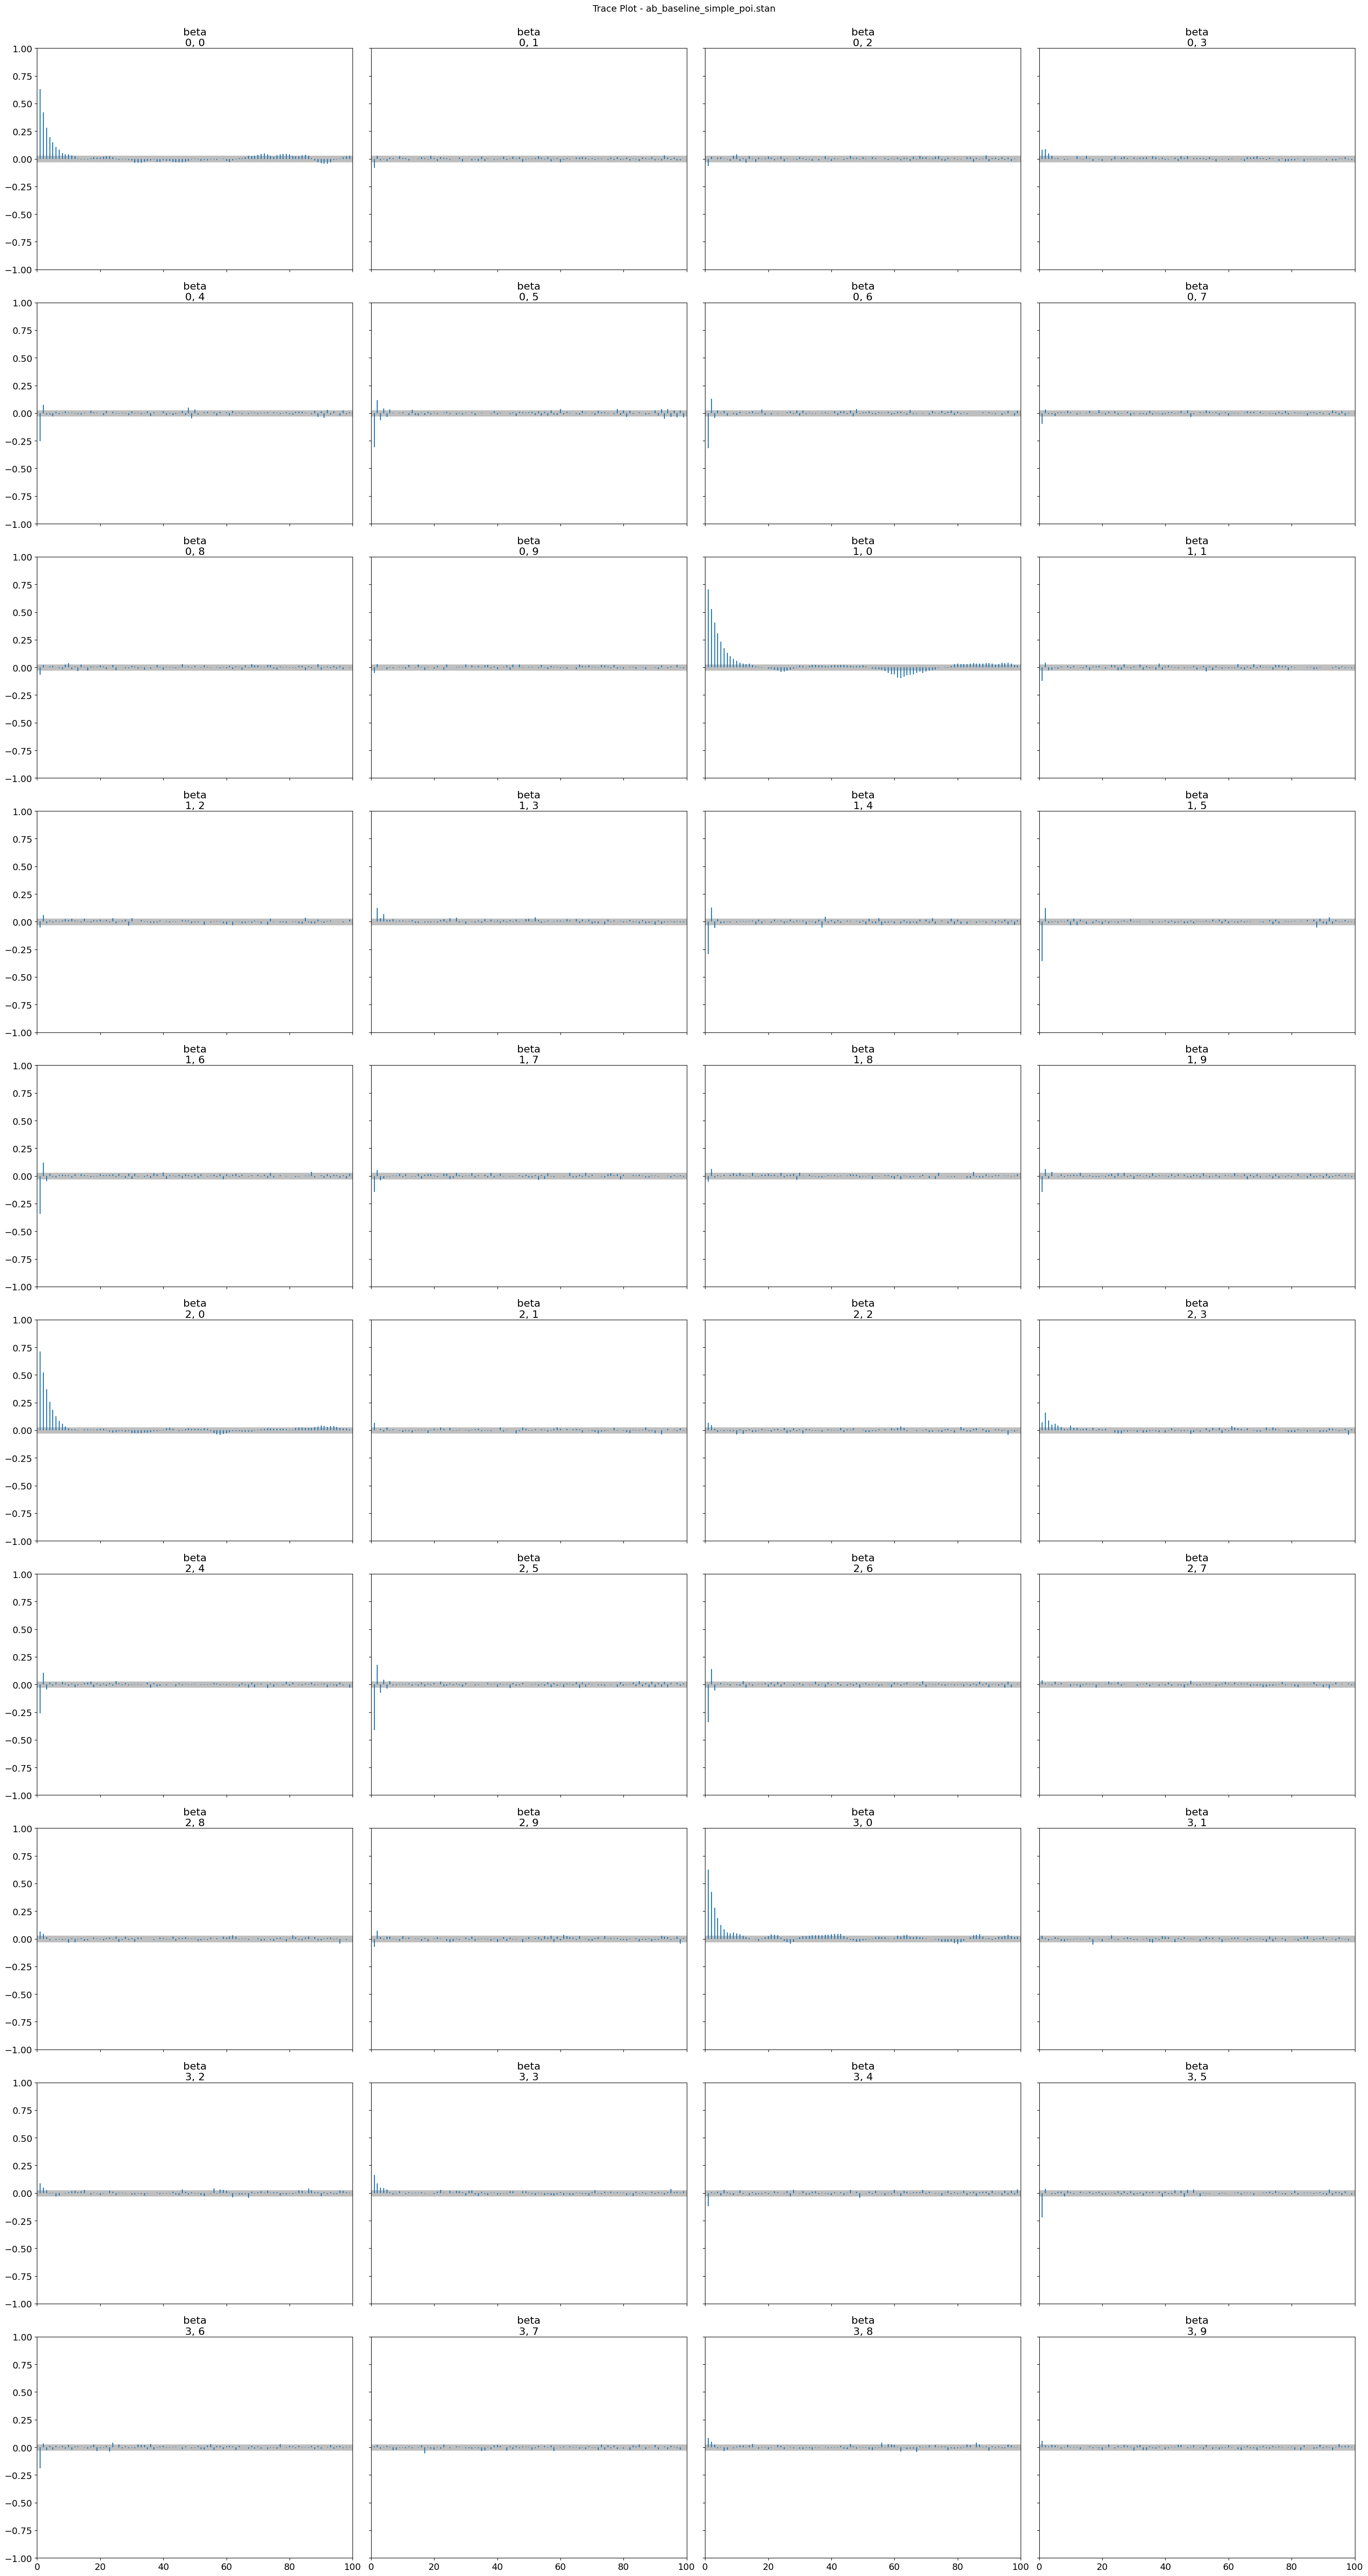

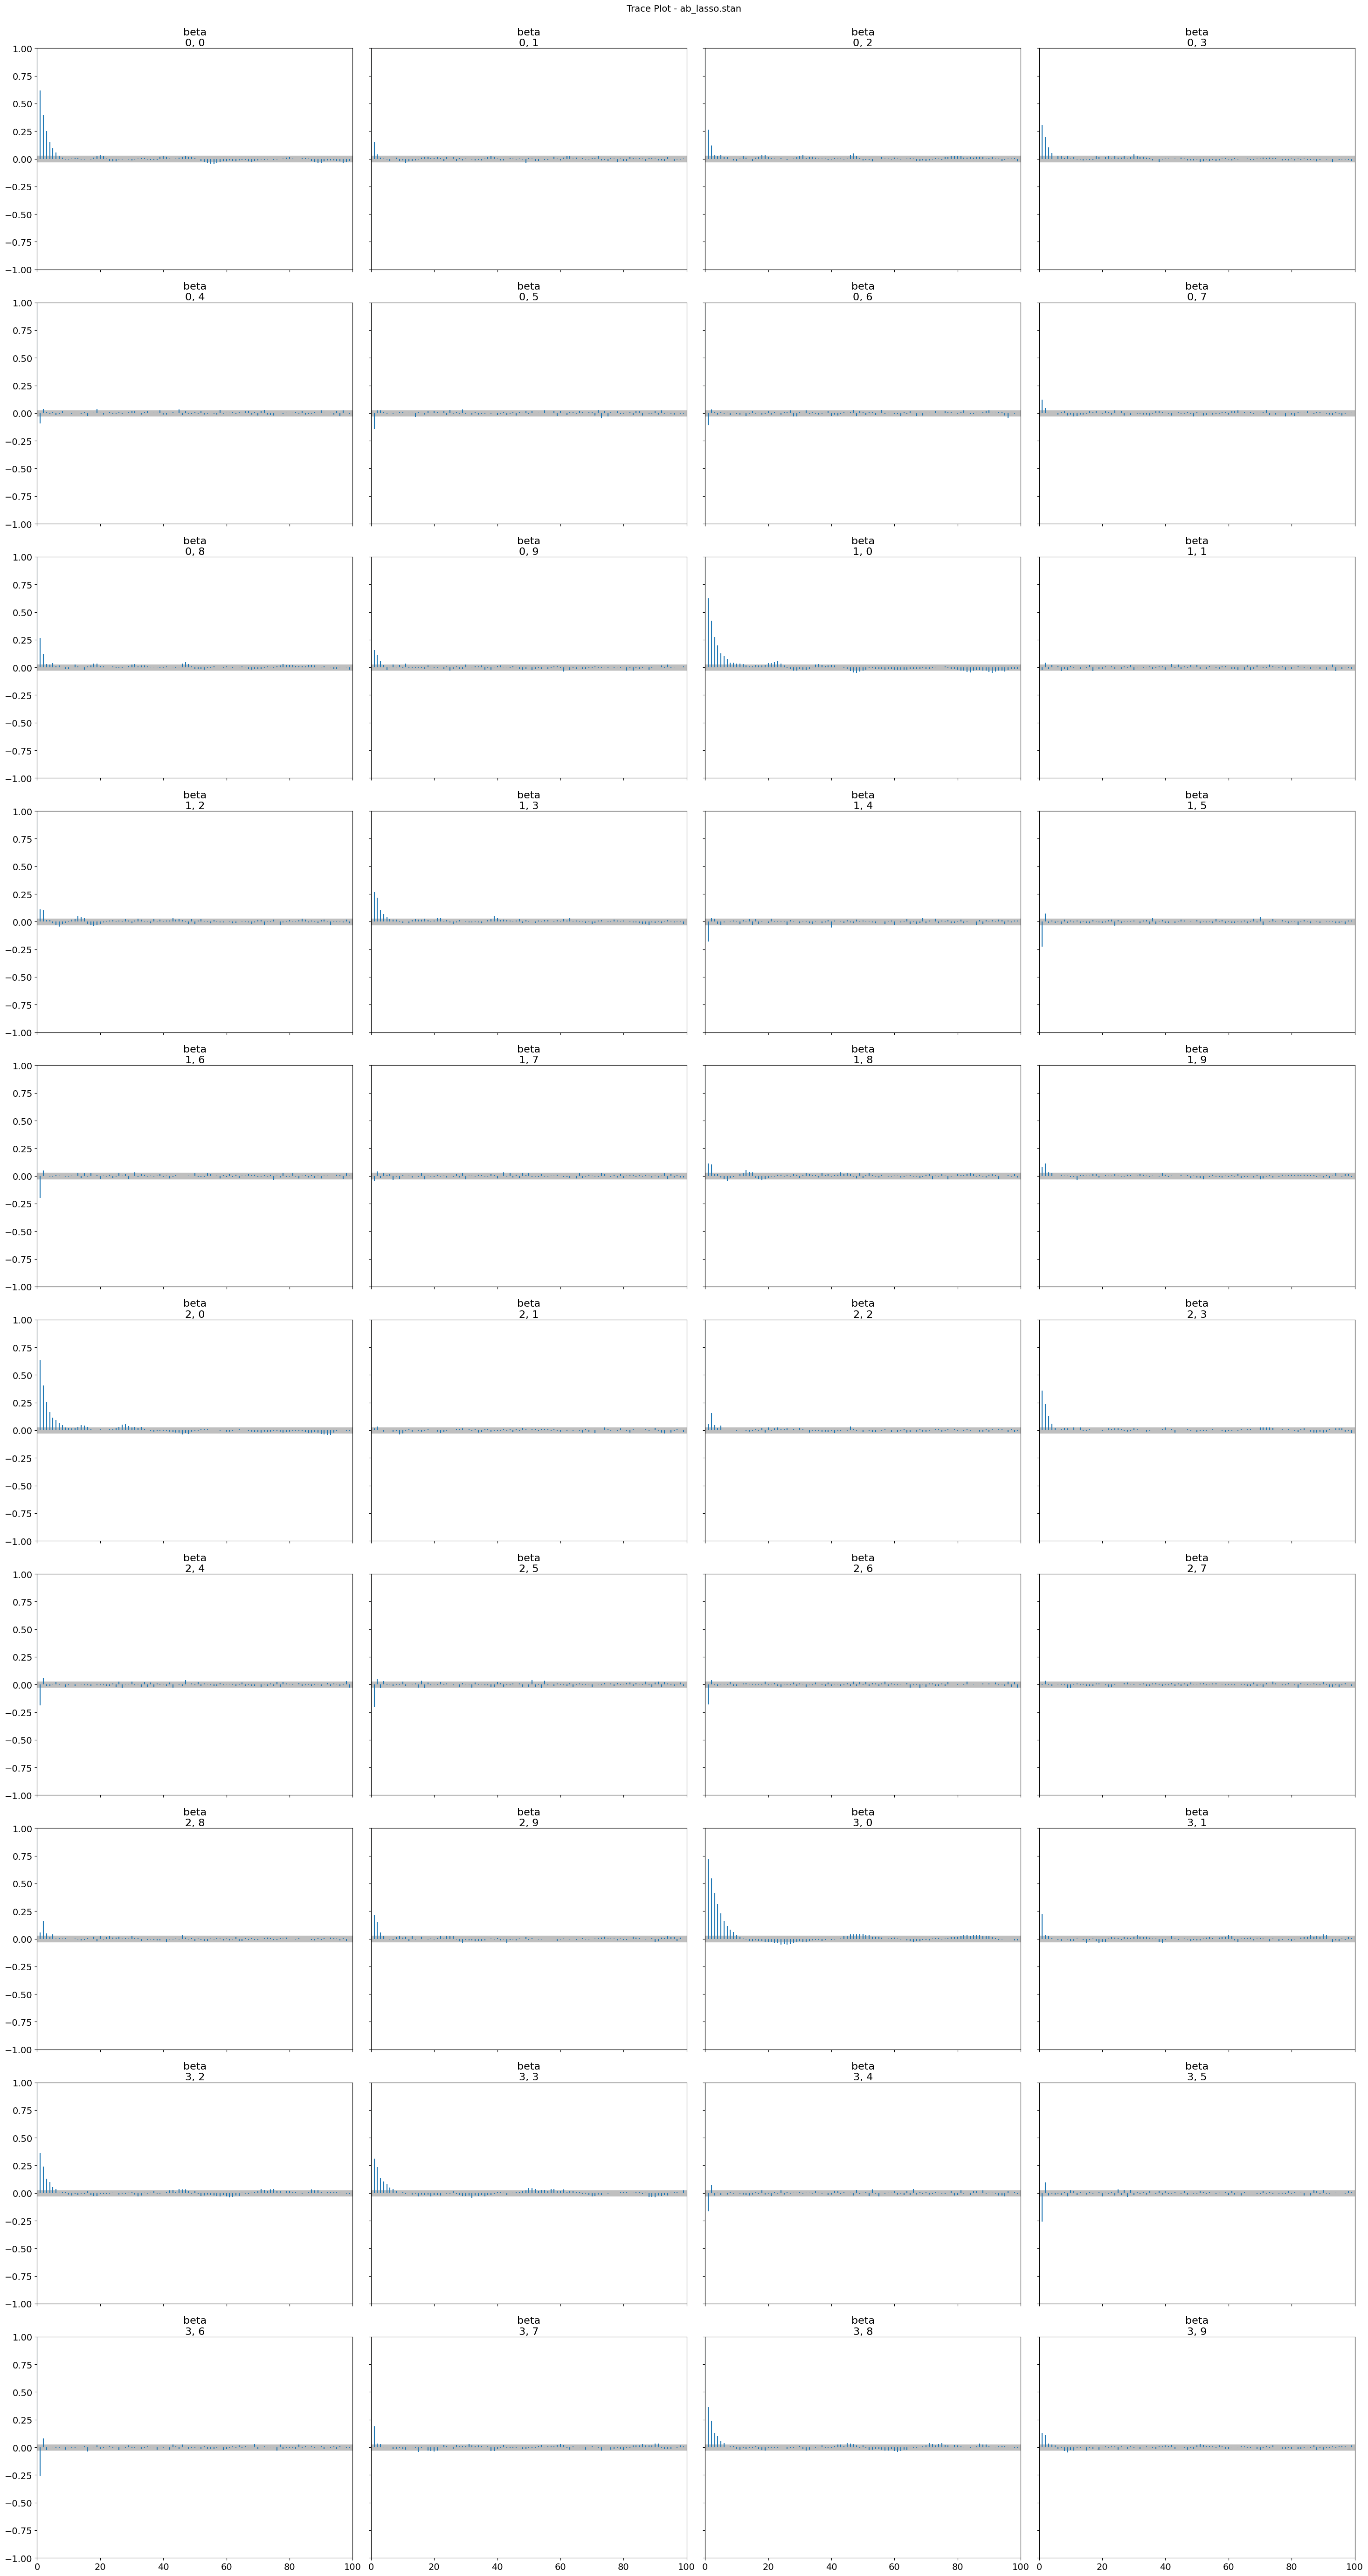

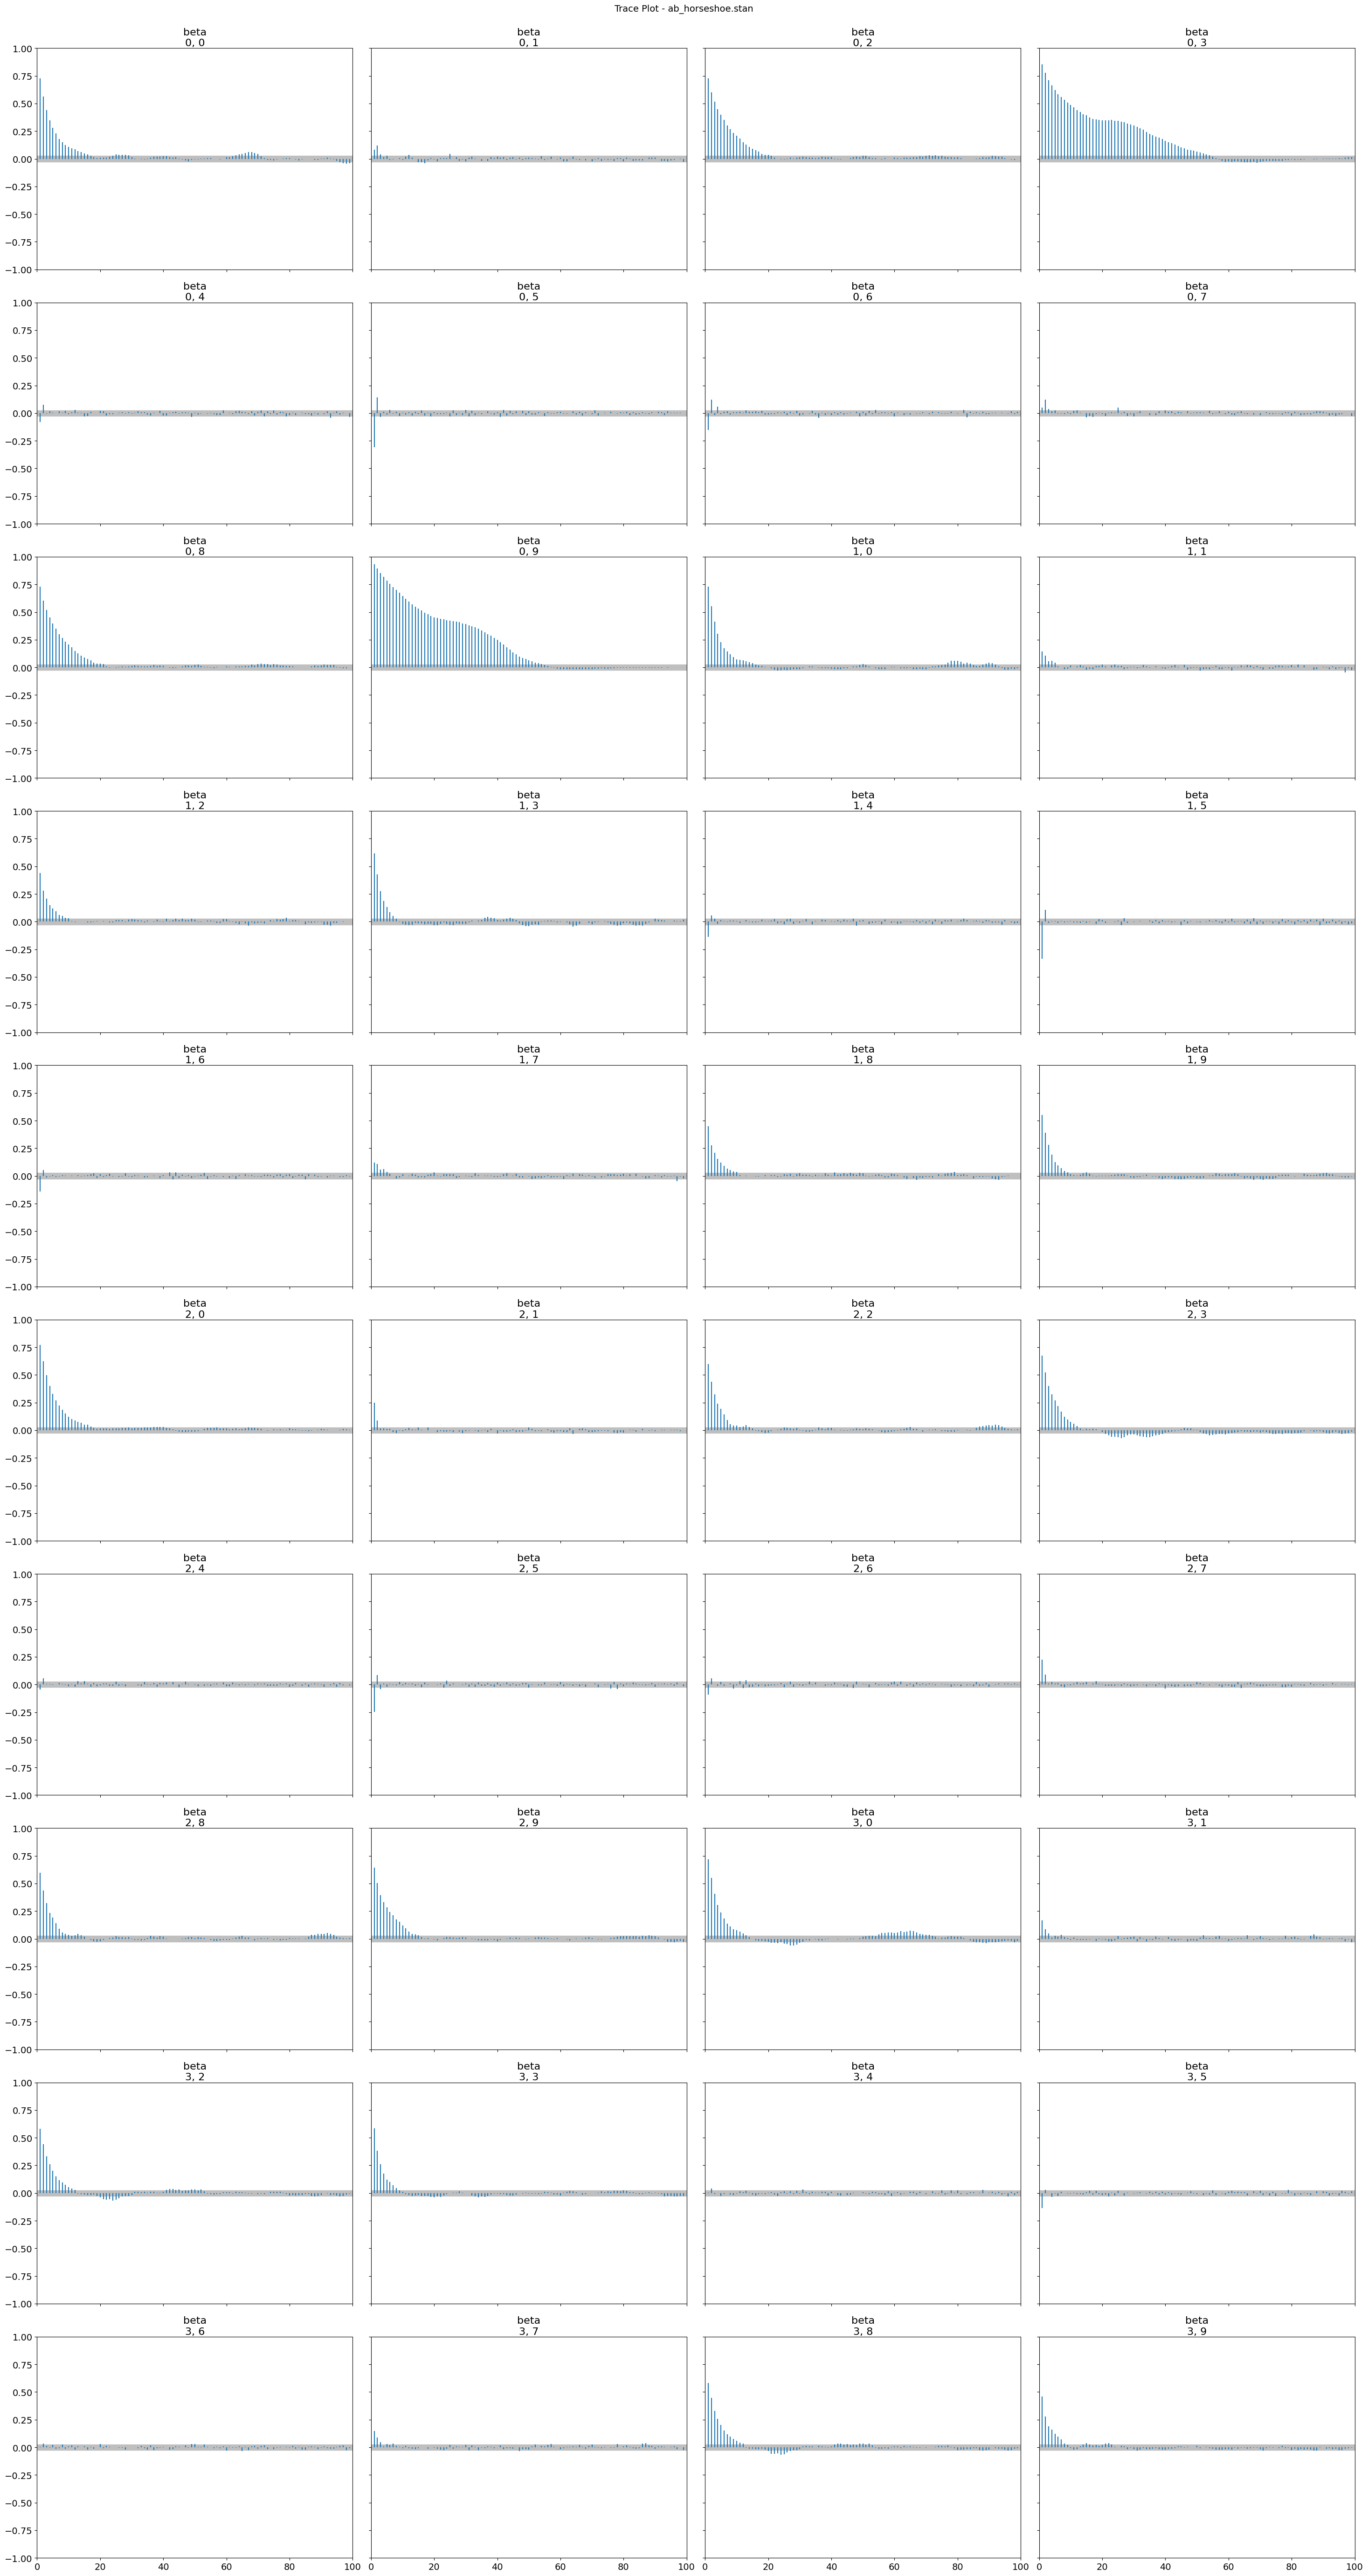

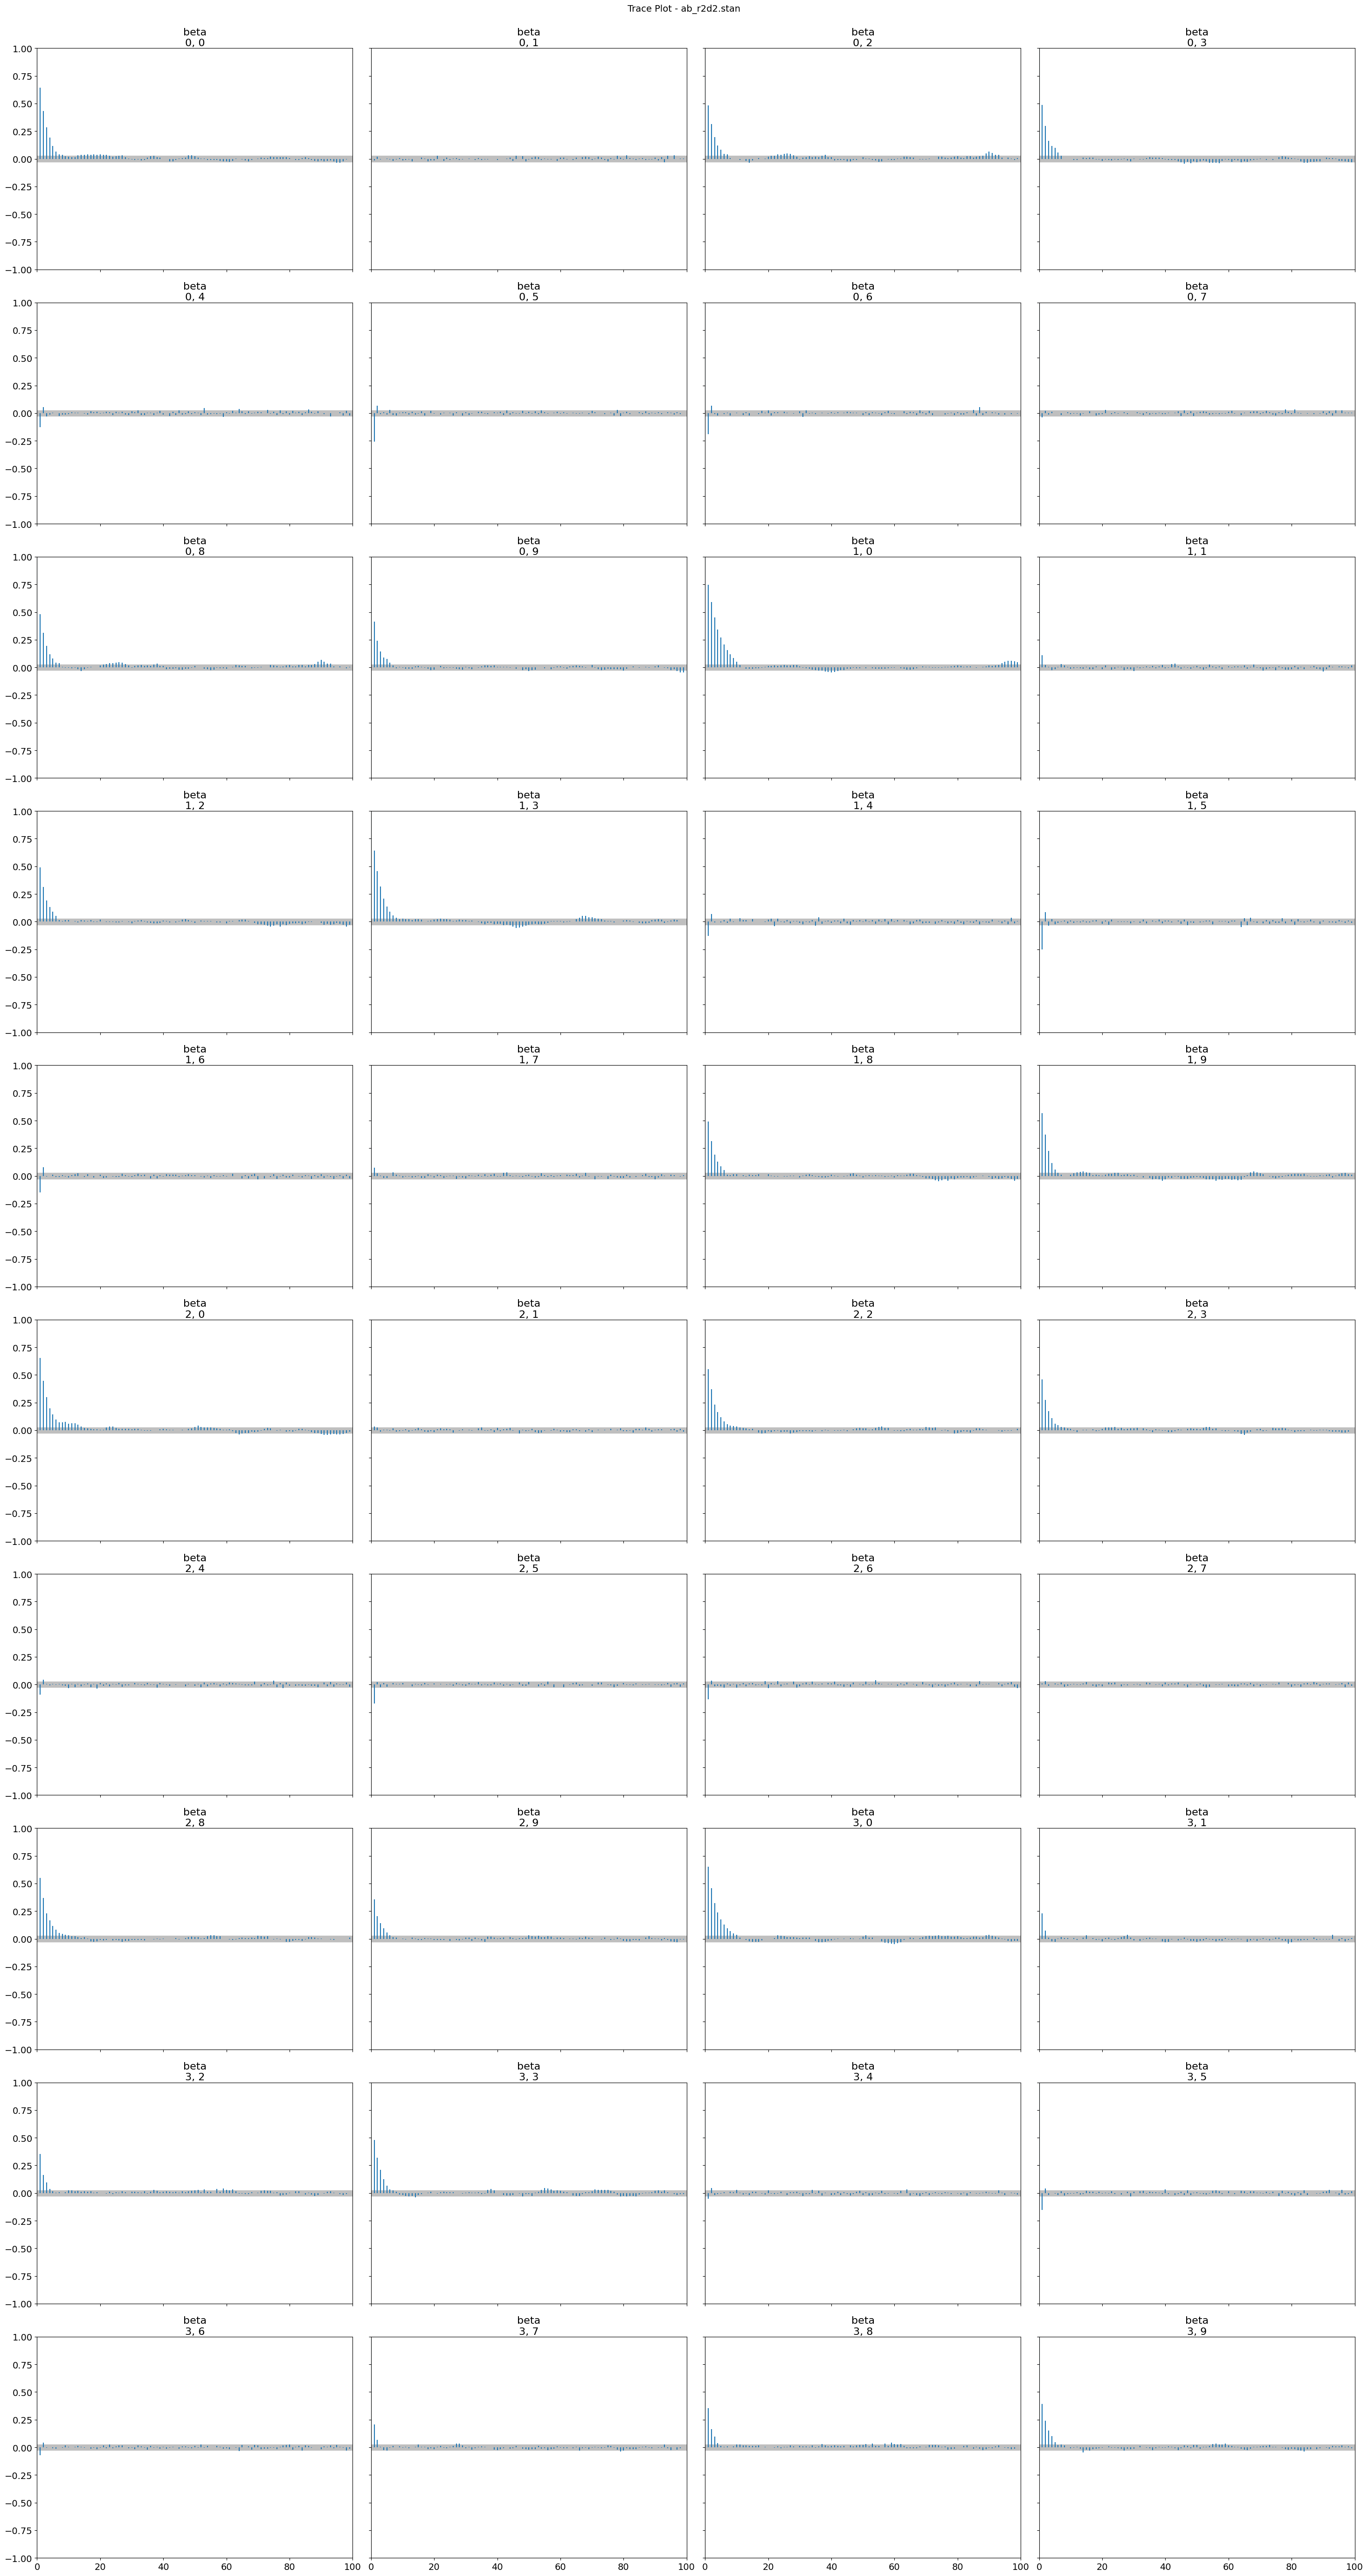

In [ ]:

for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_autocorr(poi_glm_data, var_names=["beta"])
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show() 

In [ ]:
model_names = list(models.keys())

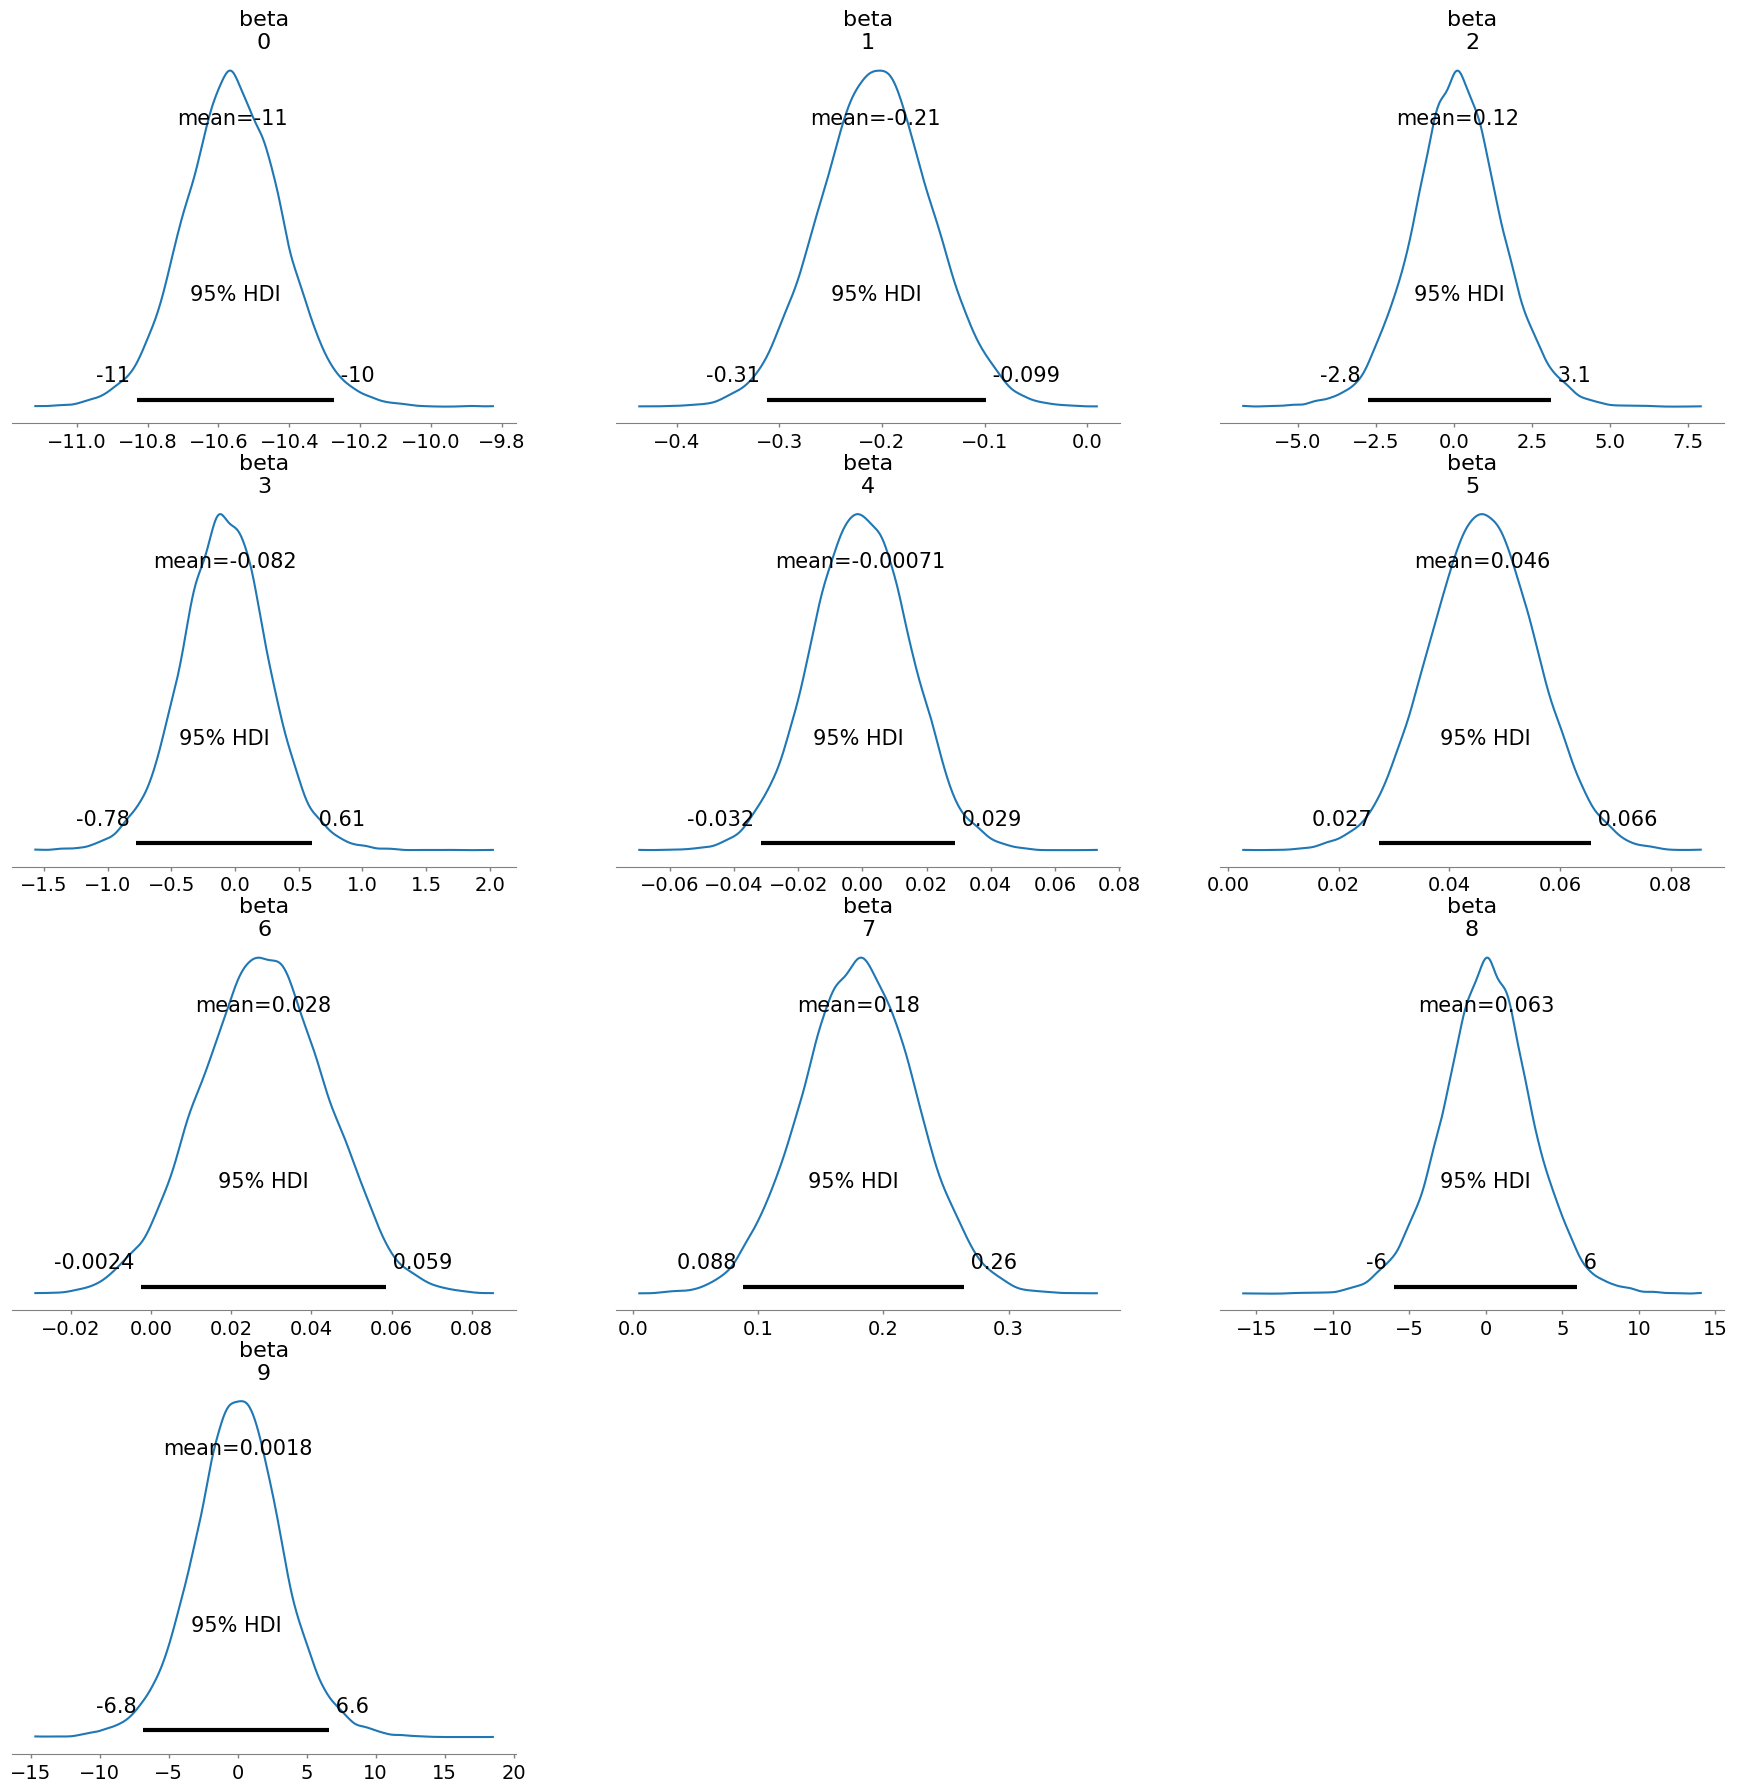

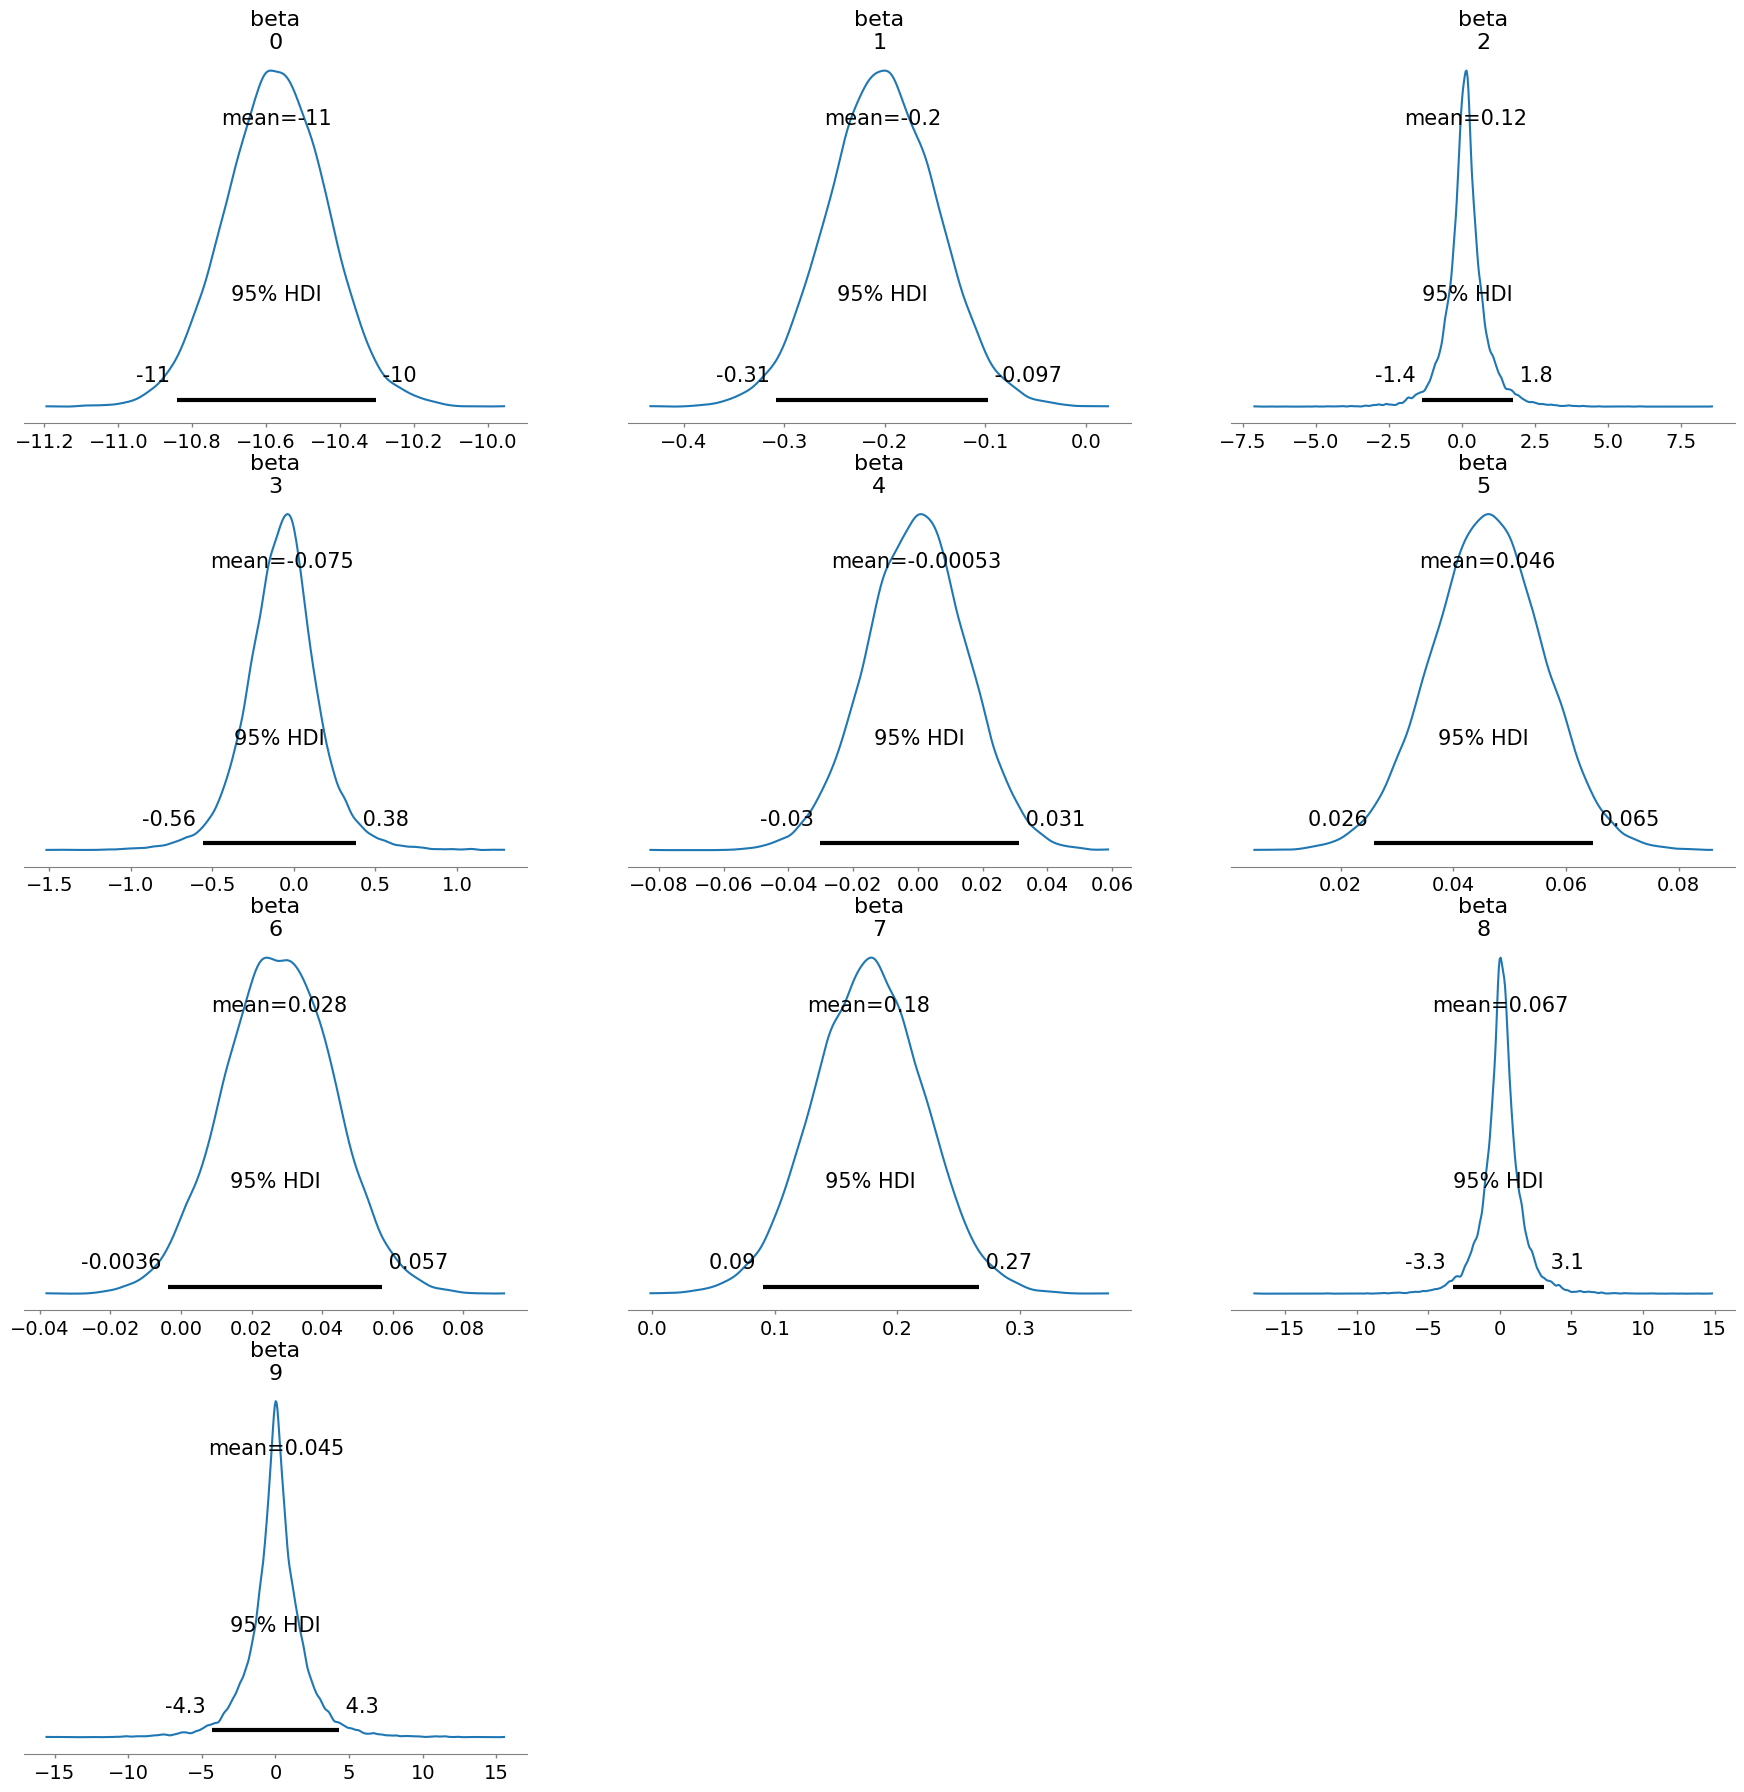

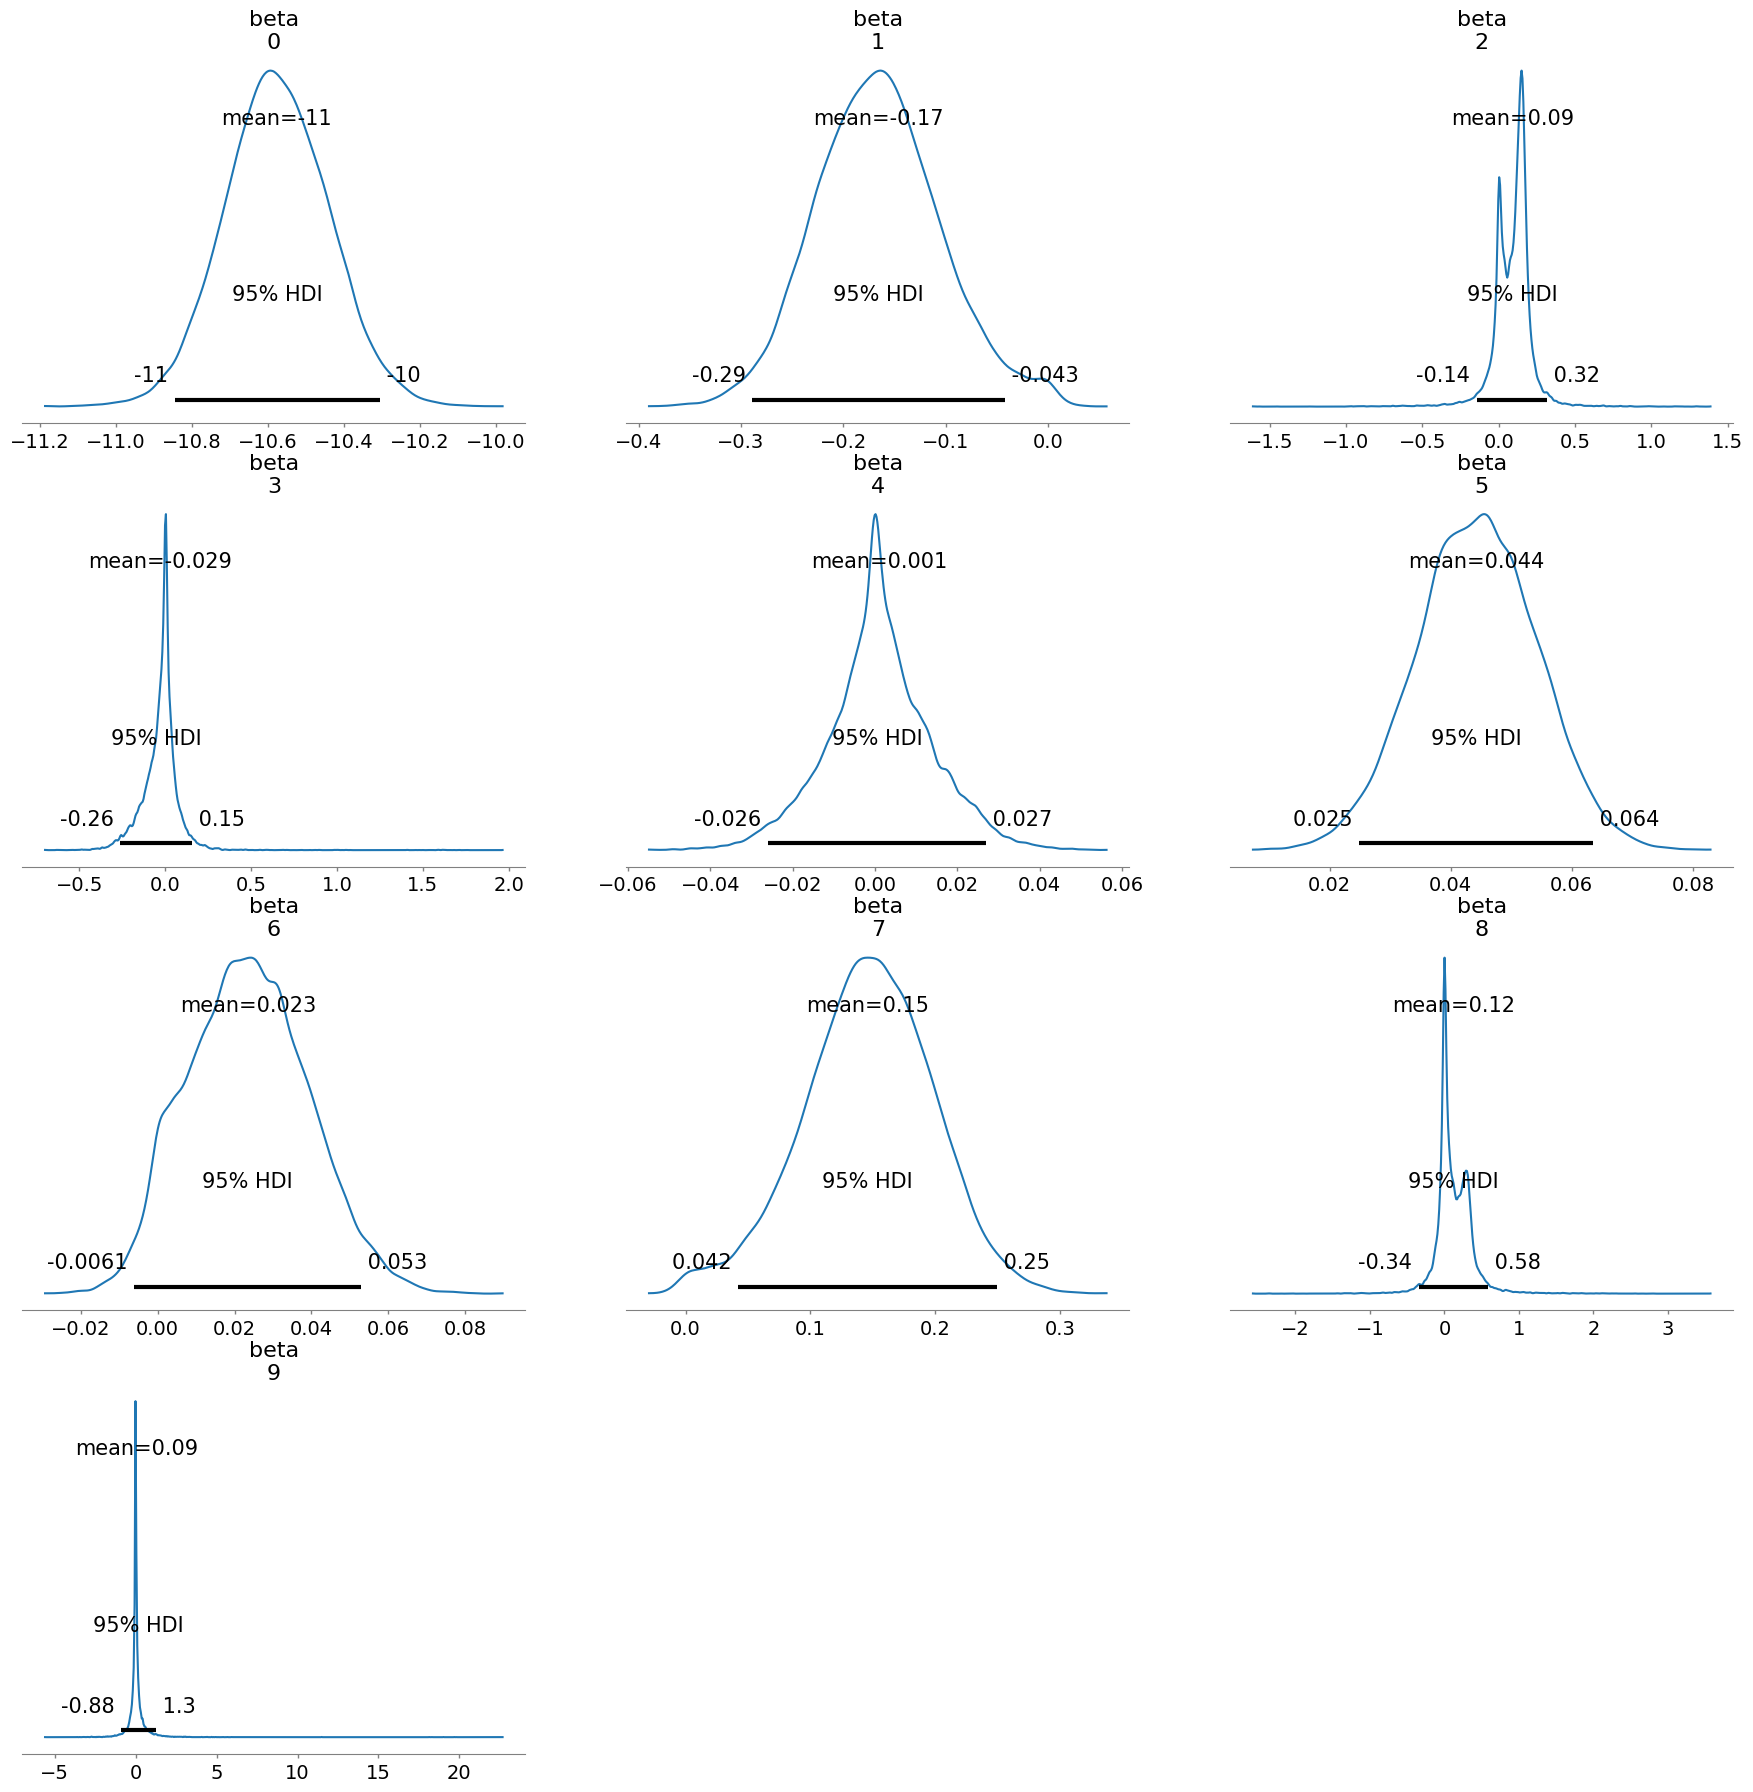

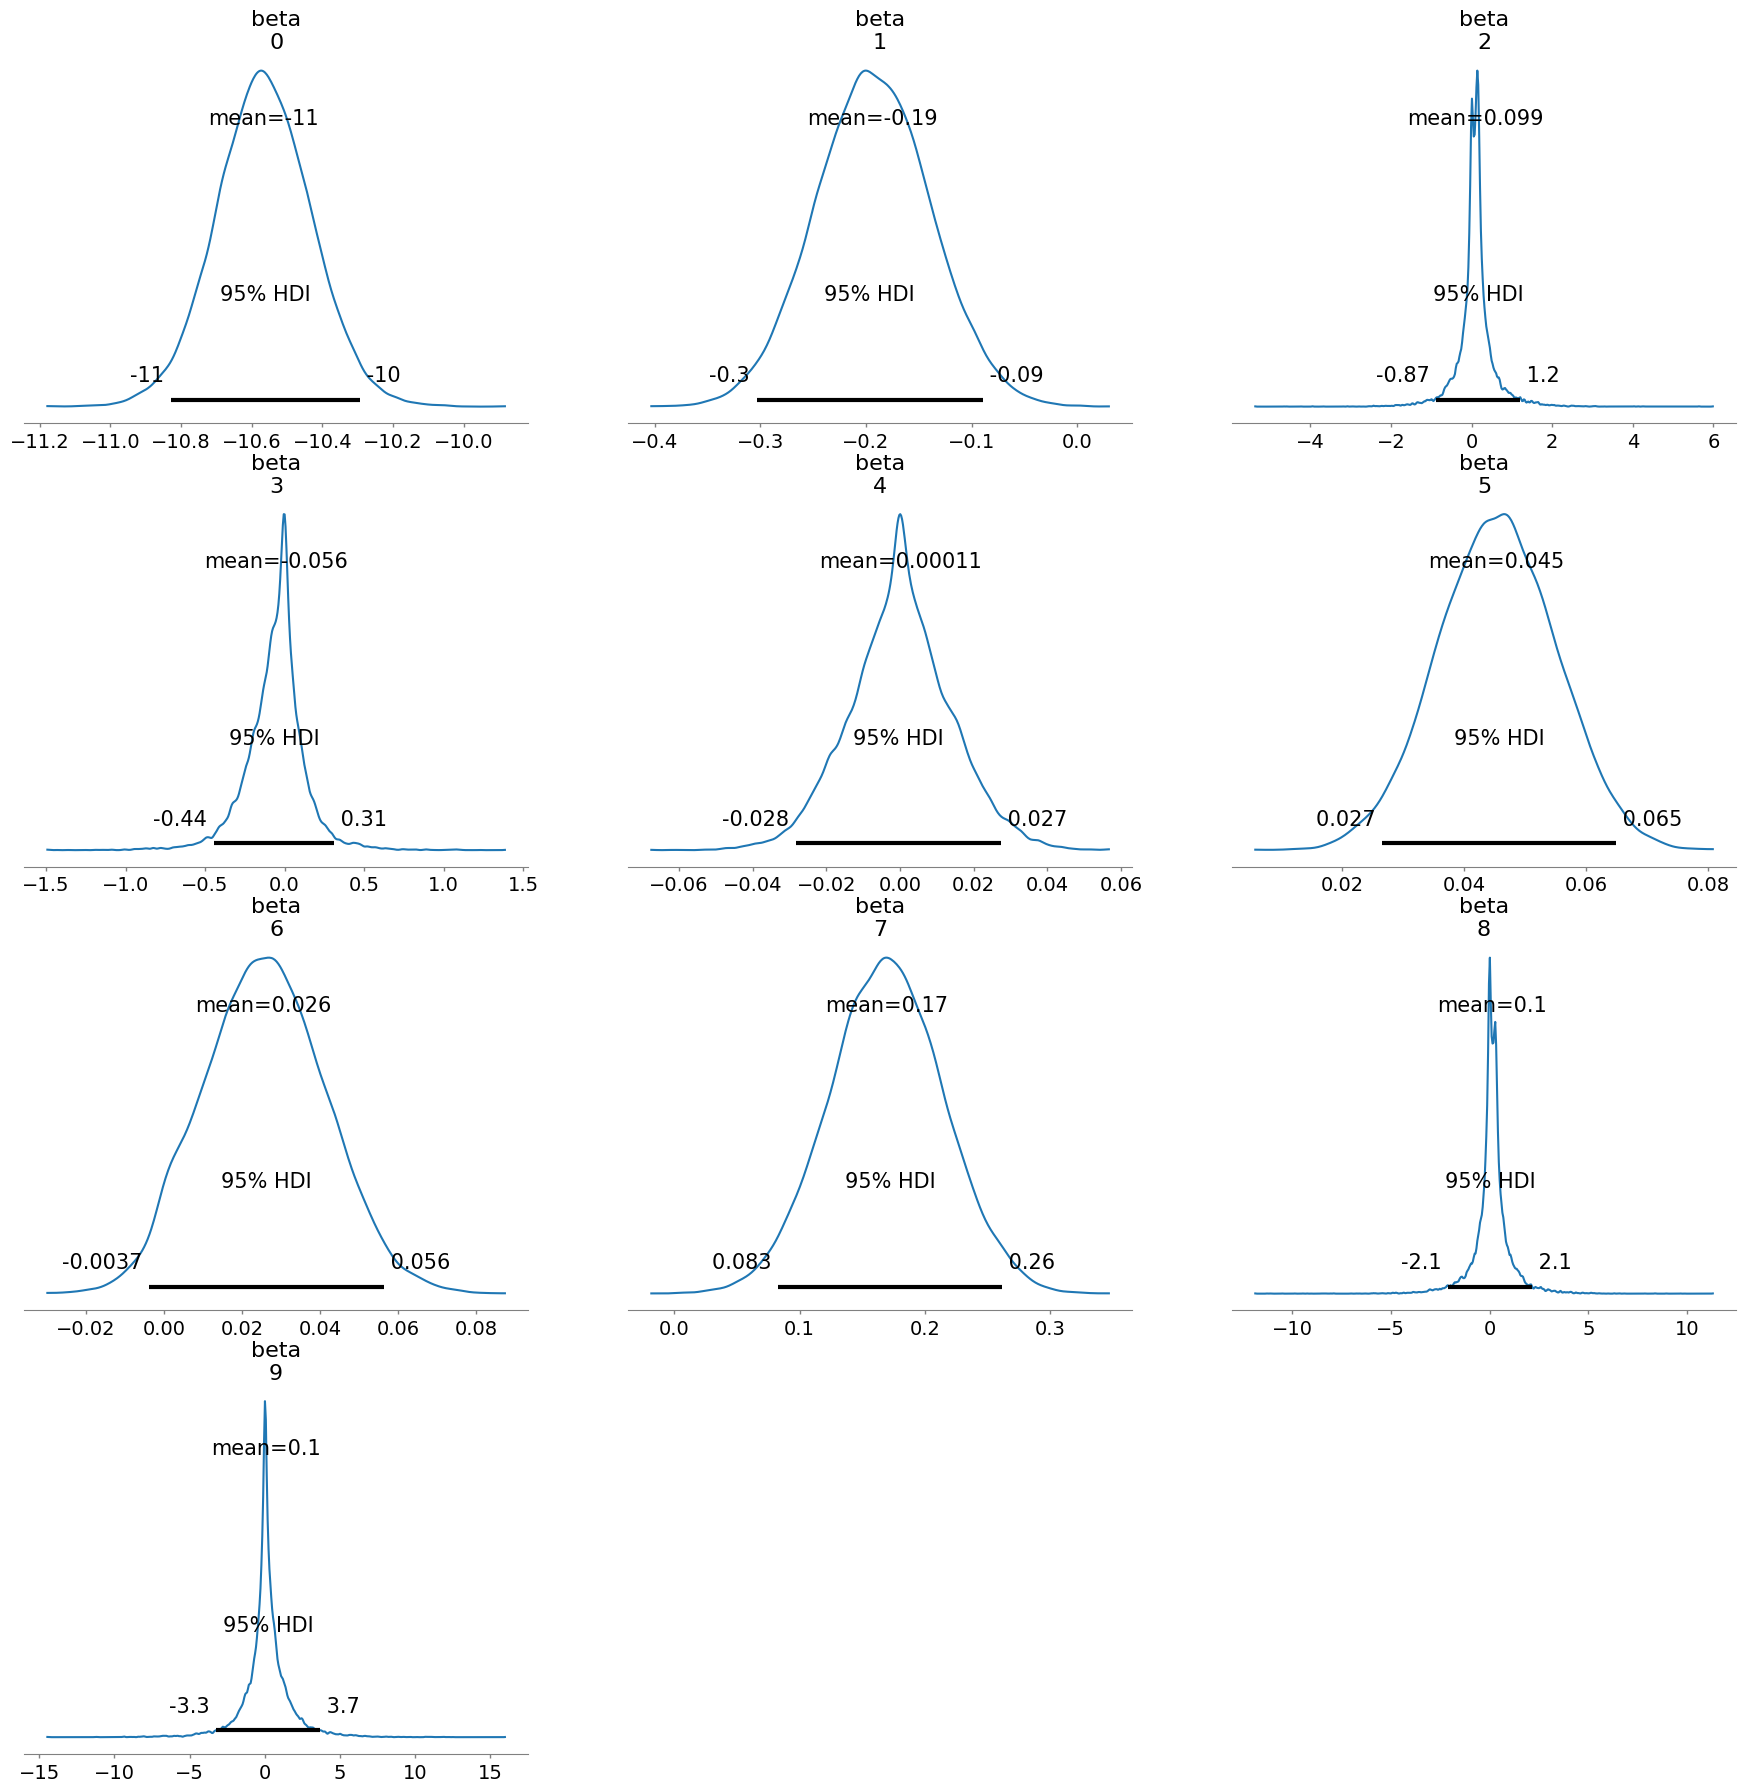

In [ ]:
for i in model_names:
    az.plot_posterior(models[i]["fit"], var_names=["beta"], hdi_prob=0.95)

In [ ]:
def plot_confident_intervals(model_fit, var_name="beta"):
    
    sum_beta = az.summary(model_fit, var_names=[var_name], hdi_prob=0.95)
    names = sum_beta.index.to_list()[1:]
    mean  = sum_beta["mean"].values[1:]
    low   = sum_beta["hdi_2.5%"].values[1:]
    high  = sum_beta["hdi_97.5%"].values[1:]
    y = np.arange(len(names))

# Generate colors based on array length
    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    plt.figure(figsize=(6, 3))
    for i in range(len(names)):
        plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
        plt.plot(mean[i], y[i], "o", color=colors[i])

    plt.axvline(0, color="black", ls="--", alpha=0.7)
    plt.yticks(y, names)
    plt.xlabel("beta (log scale effect)")
    plt.title("Posterior 95% HDI — beta")
    plt.tight_layout()
    plt.show()

ab_baseline_simple_poi.stan


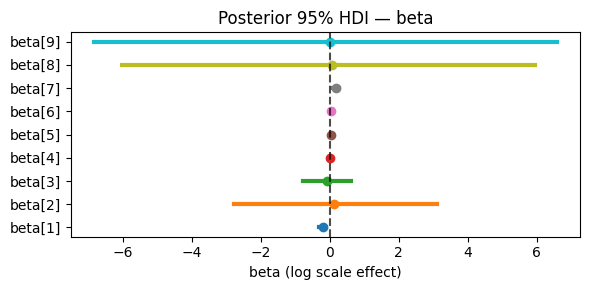

ab_lasso.stan


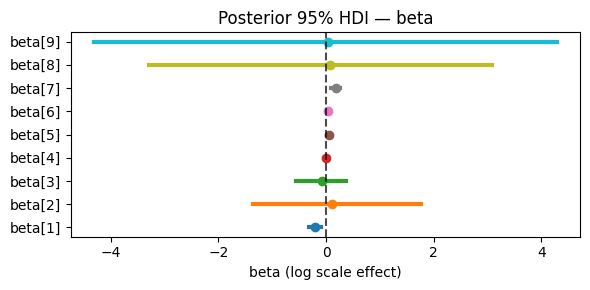

ab_horseshoe.stan


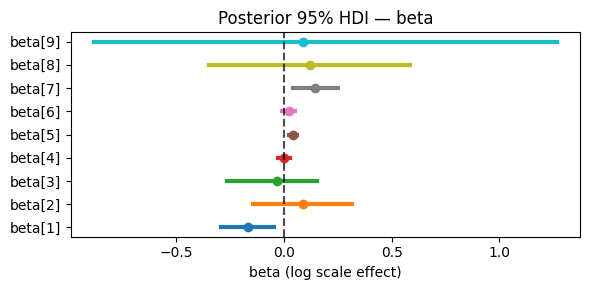

ab_r2d2.stan


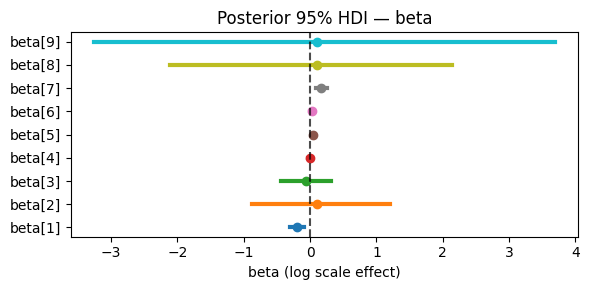

In [ ]:
for i in model_names:
    print(i)
    plot_confident_intervals(models[i]["fit"], var_name="beta")

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/py


=== LOO COMPARISON ===
                             rank     elpd_loo       p_loo  elpd_diff  \
ab_r2d2.stan                    0 -1597.382405  120.290365   0.000000   
ab_baseline_simple_poi.stan     1 -1597.974754  120.718489   0.592349   
ab_lasso.stan                   2 -1598.553038  121.484829   1.170633   
ab_horseshoe.stan               3 -1601.244239  124.582413   3.861834   

                                   weight         se       dse  warning scale  
ab_r2d2.stan                 1.000000e+00  79.663845  0.000000     True   log  
ab_baseline_simple_poi.stan  0.000000e+00  79.783248  1.078150     True   log  
ab_lasso.stan                4.992983e-16  79.779499  0.765476     True   log  
ab_horseshoe.stan            0.000000e+00  80.239861  2.067413     True   log  


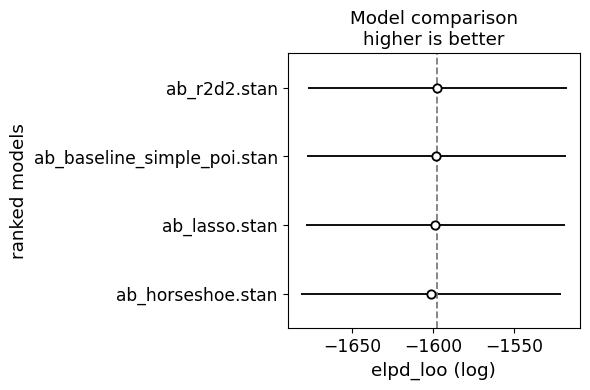

In [ ]:
compare_dict = {
}
for key in models:
    compare_dict[key] = models[key]["az"]

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/a


=== WAIC COMPARISON ===
                             rank    elpd_waic      p_waic  elpd_diff  \
ab_baseline_simple_poi.stan     0 -1594.570470  117.314206   0.000000   
ab_r2d2.stan                    1 -1594.886457  117.794417   0.315986   
ab_lasso.stan                   2 -1595.116665  118.048457   0.546195   
ab_horseshoe.stan               3 -1597.052542  120.390716   2.482072   

                               weight         se       dse  warning scale  
ab_baseline_simple_poi.stan  0.898372  79.505629  0.000000     True   log  
ab_r2d2.stan                 0.000000  79.568462  0.866613     True   log  
ab_lasso.stan                0.000000  79.560890  0.344274     True   log  
ab_horseshoe.stan            0.101628  79.886529  2.613333     True   log  


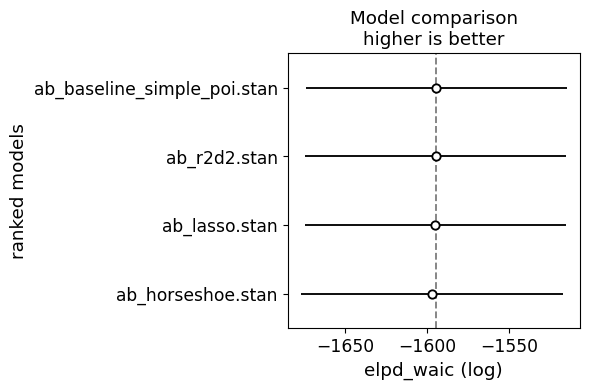

In [ ]:
comparison_waic = az.compare(compare_dict, ic="waic")
print("\n=== WAIC COMPARISON ===")
print(comparison_waic)

az.plot_compare(comparison_waic, insample_dev=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def select_by_hdi(az_data, var_name="beta", credible_mass=0.95, 
                  covariate_names=["Intercept", "IBU", "DMSO", "Temp"]):
    summary = az.summary(az_data, var_names=[var_name], 
                        hdi_prob=credible_mass)
    
    results = []
    for idx, name in enumerate(covariate_names):
        row = summary.iloc[idx]
        hdi_low = row[f"hdi_{(1-credible_mass)/2*100:.1f}%"]
        hdi_high = row[f"hdi_{(1+credible_mass)/2*100:.1f}%"]
        
        crosses_zero = (hdi_low < 0) and (hdi_high > 0)
        
        results.append({
            'variable': name,
            'mean': row['mean'],
            'hdi_low': hdi_low,
            'hdi_high': hdi_high,
            'crosses_zero': crosses_zero,
            'selected': not crosses_zero
        })
    
    return pd.DataFrame(results)

print("=" * 40)
print("HDI-BASED SELECTION (95% credible intervals)")
print("=" * 40)

for model_name in model_names:
    print(f"\n{model_name}:")
    result = select_by_hdi(az_data=models[model_name]["az"], credible_mass=0.95)
    # print(result)
    print(f"Selected: {result[result['selected']]['variable'].tolist()}")

HDI-BASED SELECTION (95% credible intervals)

ab_baseline_simple_poi.stan:
Selected: ['Intercept', 'IBU']

ab_lasso.stan:
Selected: ['Intercept', 'IBU']

ab_horseshoe.stan:
Selected: ['Intercept', 'IBU']

ab_r2d2.stan:
Selected: ['Intercept', 'IBU']


In [ ]:
def posterior_inclusion_probability(az_data, var_name="beta", 
                                   threshold=None,
                                   covariate_names=["Intercept", "IBU", "DMSO", "Temp"], prob=0.5):
    """
    Calculate P(|beta_j| > threshold | data)
    
    If threshold is None, uses practical significance = 0.1 * posterior SD for each variable
    (Rule of thumb: effects smaller than 10% of SD are negligible)
    """
    samples = az_data.posterior[var_name].values
    n_chains, n_draws, p = samples.shape
    
    results = []
    for j in range(p):
        beta_j = samples[:, :, j].flatten()
        
        if threshold is None:
            thresh = 0.1 * np.std(beta_j)
        else:
            thresh = threshold
        
        pip = np.mean(np.abs(beta_j) > thresh)
        
        prob_positive = np.mean(beta_j > thresh)
        prob_negative = np.mean(beta_j < -thresh)
        
        results.append({
            'variable': covariate_names[j],
            'threshold_used': thresh,
            'PIP': pip,
            'P(β > thresh)': prob_positive,
            'P(β < -thresh)': prob_negative,
            'median': np.median(beta_j),
            'sd': np.std(beta_j),
            'selected': pip > prob  
        })
    
    return pd.DataFrame(results)

print("\n" + "=" * 60)
print("POSTERIOR INCLUSION PROBABILITY")
print("=" * 60)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("\n--- Auto threshold (10% of posterior SD) ---")
    result = posterior_inclusion_probability(az_data=models[model_name]["az"], prob=0.8)
    #print(result[['variable', 'threshold_used', 'PIP', 'median', 'sd', 'selected']])
    print(f"Selected (PIP > 0.8): {result[result['selected']]['variable'].tolist()}")
    
    print("\n--- Fixed threshold = 0.1 (practical significance) ---")
    result_fixed = posterior_inclusion_probability(
        models[model_name]["az"],
        threshold=0.1, prob=0.8
    )
    #print(result_fixed[['variable', 'PIP', 'median', 'selected']])
    print(f"Selected: {result_fixed[result_fixed['selected']]['variable'].tolist()}")


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:

--- Auto threshold (10% of posterior SD) ---


IndexError: list index out of range

In [ ]:
def cross_model_selection(models_dict, model_names, 
                         covariate_names=["Intercept", "IBU", "DMSO", "Temp"],
                         methods=['hdi', 'pip'], pip_th = None, pip_prob=0.5):
    """
    Variable selected if chosen by majority of models
    """
    selection_matrix = []
    
    for model_name in model_names:
        for method in methods:
            if method == 'hdi':
                result = select_by_hdi(models_dict[model_name]["az"], 
                                      covariate_names=covariate_names)
            if method == 'pip':
                result = posterior_inclusion_probability(
        models_dict[model_name]["az"],
        threshold=pip_th, prob=pip_prob
    )   
            selection_matrix.append(result['selected'].values)
    
    selection_matrix = np.array(selection_matrix)
    
    selection_count = selection_matrix.sum(axis=0)
    
    consensus_df = pd.DataFrame({
        'variable': covariate_names,
        'n_models_selected': selection_count,
        'proportion': selection_count / (len(model_names) * len(methods)),
        'consensus_selected': selection_count >= (len(model_names) * len(methods) / 2)
    })
    
    return consensus_df

working_models = model_names

print("\n" + "=" * 60)
print("CROSS-MODEL CONSENSUS")
print("=" * 60)


CROSS-MODEL CONSENSUS


: 

: 

: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi', 'pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                 14    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                 14    1.000000                True
3       Temp                  5    0.357143               False

Final selection: ['Intercept', 'DMSO']


: 

: 

: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi'])
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


: 

: 

: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  7         1.0                True
2       DMSO                  7         1.0                True
3       Temp                  7         1.0                True

Final selection: ['Intercept', 'IBU', 'DMSO', 'Temp']


: 

: 

: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8, pip_th=0.1)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


: 

: 

: 

: 

In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                  7    1.000000                True
3       Temp                  5    0.714286                True

Final selection: ['Intercept', 'DMSO', 'Temp']


: 

: 

: 

: 


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.583636  0.416364      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.267955  0.732045      True
Selected (PIP > 0.5): ['Intercept', 'IBU', 'DMSO', 'Temp']

ab_regularized_horseshoe1.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.564227  0.435773      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.376682  0.623318      True
Selected (PIP > 0.5): ['Intercept', 'IBU', 'DMSO', 'Temp']

ab_regularized_horseshoe2.stan:
    variable  PIP  P(β > 0)  P(β < 0)  selected
0  Intercept  1.0  0.000000  1.000000      True
1        IBU  1.0  0.563091  0.436909      True
2       DMSO  1.0  1.000000  0.000000      True
3       Temp  1.0  0.363000  0.637000      True
Selected (PIP > 0.5): ['Intercept

: 

: 

: 

: 

# comparison_loo 
very expensive -> I need to fit the sample with removing each covariate -> does not make sense. I will include only two covariate to see which one is better (TEMP, DMSO)